## Linearized Flight Dynamics

The nonlinear equations of motion for an aircraft are valid in general so long as the basic assumptions of rigid body motion are not violated -- flexibility, slosh, actuator dynamics, and other effects outside the scope of the equations could require enhancements, although these enhancements do not necessarily need to be nonlinear. However the nonlinear equations can only deliver a time history for a given initial condition and input history. This has limited value when we want to talk more generally about how the system responds. By representing the aircraft response as a linear system, we can use the extensive set of analytical tools that are applicable to linear systems. These include:

- Eigenvalue analysis of the system to determine response frequencies, damping, and modes
- The ability to connect basic system parameters to the system dynamics (in some cases)
- A linear representation enables both classical and state-space based ("modern") control design approaches for tuning filters/gains and writing margins

The scope of this section is intended to demonstrate linearization is a viable approach, develop the standard decoupled longitudinal & lateral/direction linearizations, and demonstrate some items of interest. Further detailed investigations into specific features of the response will follow in a later section.

As with the nonlinear flight dynamics section, new code will be written in-line. The code previously written in that section will be imported from an external Python file.


### Demonstrating Linearization Works

Most textbooks go right from the nonlinear equations into the linearized equations. In the previous section, we actually implemented the nonlinear equations and demonstrated they can reasonably represent the documented response of an example aircraft. Before jumping into any analytical work, we'll show that a linearized version of that same system actually does do a good job of representing the nonlinear response. 

The nonlinear equation of motion can be evaluated at a trim state $\mathbf{x}_0$ with associated observable outputs $\mathbf{y_0}$ and equilibrium input $\mathbf{u}_0$. Under assumptions of "small" disturbances, the overall response can then be approximated as "small" transient corrections $\mathbf{x}_0$ and $\mathbf{y}_0$ to the original equilibrium solutions, with associated control inputs $\Delta \mathbf{u}(t)$.

$$
\mathbf{x}(t) = \mathbf{x}_0 + \Delta \mathbf{x}(t, \Delta \mathbf{u}_0 + \Delta \mathbf{u}(t))
$$
$$
\mathbf{y}(t) = \mathbf{y}_0 + \Delta \mathbf{y}(t)
$$

The control differentials $\Delta \mathbf{u}$ do not necessarily need to be "small," except to the extent that they keep the actual transient as "small." The very important question of "how small is small" (Prof. Dan Kammer would often use this in our satellite and nonlinear dynamics courses) is an interesting one that we will revist later.

To represent the linear transients we will use a state-space approach, which is extremely flexible for both low and high-order systems. This is the approach used by Garza & Morelli, starting with Eq. (18). We'll use standard state-space nomenclature but take care to carry along the $\Delta$ modifiers (this looks ugly, but the distinction between total response and linear transient is important enough to butcher our typesetting just a bit):

$$
\mathbf{\Delta\dot{x}} = \mathbf{A}\Delta\mathbf{x} + \mathbf{B}\Delta\mathbf{u}
$$
$$
\mathbf{\Delta\dot{y}} = \mathbf{C}\Delta\mathbf{x} + \mathbf{D}\Delta\mathbf{u}
$$

For a state vector $\Delta\mathbf{x}$ (length $n_{state}$), input vector $\Delta\mathbf{u}$ (length $n_{input}$), and output vector $\Delta\mathbf{y}$ (length $n_{output}$). One aspect I'll reinforce with this representation is that the states are not visible or accessible to us externally; we can only see the **outputs** of the system. (This is a difference from the Garza & Morelli approach). The system matrices can be obtained by taking finite differences about a trim condition $\mathbf{x}_{0}$, $\mathbf{u}_{0}$. The $\mathbf{A}_i$ notation indicates calculation of column $i$ of each matrix associated with a change in element $i$; $\Delta x_i$ and $\Delta u_i$ are all zeros with the exception of element $i$. The function $f(\mathbf{x}, \mathbf{u})$ is the equation of motion providing the state derivatives at a given state, and input (time dependence is ignored here and assumed to be implicit in the state & input definitions); $g(\mathbf{x}, \mathbf{u})$ is a companion function that returns the observable outputs for the same state and input. Matrix dimensions are also listed in the subscripts; these were omitted above and will be dropped going forward but are provided below since it is easy to lose track of the appropriate dimensions of each matrix. 

$$
\mathbf{A}_{n_{state}, n_{state}} = \dfrac{\partial f(\mathbf{x}, \mathbf{u})}{\mathbf{x}} \bigg|_{\mathbf{x}_{0}, \mathbf{u}_{0}};\;\; \mathbf{A}_i \approx \dfrac{f(\mathbf{x} + \Delta \mathbf{x}_i, \mathbf{u}) - f(\mathbf{x}_{0}, \mathbf{u}_{0})}{\Delta x_i}
$$

$$
\mathbf{B}_{n_{state}, n_{input}} = \dfrac{\partial f(\mathbf{x}, \mathbf{u})}{\mathbf{u}} \bigg|_{\mathbf{x}_{0}, \mathbf{u}_{0}};\;\; \mathbf{B}_i \approx \dfrac{f(\mathbf{x}, \mathbf{u} + \Delta \mathbf{u}_i) - f(\mathbf{x}_{0}, \mathbf{u}_{0})}{\Delta u_i}
$$
$$
\mathbf{C}_{n_{output}, n_{state}} = \dfrac{\partial g(\mathbf{x}, \mathbf{u})}{\mathbf{x}} \bigg|_{\mathbf{x}_{0}, \mathbf{u}_{0}};\;\; \mathbf{C}_i \approx \dfrac{g(\mathbf{x} + \Delta \mathbf{x}_i, \mathbf{u}) - g(\mathbf{x}_{0}, \mathbf{u}_{0})}{\Delta x_i}
$$

$$
\mathbf{D}_{n_{output}, n_{input}} = \dfrac{\partial g(\mathbf{x}, \mathbf{u})}{\mathbf{u}} \bigg|_{\mathbf{x}_{0}, \mathbf{u}_{0}};\;\; \mathbf{D}_i \approx \dfrac{g(\mathbf{x}, \mathbf{u} + \Delta \mathbf{u}_i) - g(\mathbf{x}_{0}, \mathbf{u}_{0})}{\Delta u_i}
$$

Calculation of these matrices for an Aircraft object is performed in the function below. The function returns a Scipy.signal [LinearTimeInvariant](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.lti.html) object in state-space format, which can be used in conjunction with the [lsim](https://docs.scipy.org/doc//scipy-1.16.2/reference/generated/scipy.signal.lsim.html) function to easily generate time histories for a given input history. The initial outputs $\mathbf{y}_0$ associated with states $\mathbf{x}_0$ and inputs $\mathbf{u}_0$ at trim state are also provided as a convenience for plotting the results of the linear simulation.


In [9]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import lti, lsim

from nonlinear_flight_dynamics import GET_F106, get_trim, get_initial_state, eom_6dof, RHO_SL_SLUG_FT3, G_FT_S2


RAD_DEG = 180/np.pi

def get_linearized_6dof(aircraft, airspeed, trim_X0, rho = RHO_SL_SLUG_FT3):
    """
    Obtains linearized state-space matrices for the supplied aircraft object
    at specified airspeed and trim conditions. Aircraft must be set at a control
    setting and throttle level that puts it at or near a valid trim state,
    or the linearization will be invalid

    Parameters
    ----------
    aircraft : Aircraft
        Aircraft object which implements "get_thrust," "get_mass_props," and 
        "get_aero_coeffs" properties
    airspeed : float
        True airspeed for trim
    trim_X0 : array
        Trim initial conditions for the 6DOF solver
    rho : float, optional
        Atmospheric density at trim altitude. Default value is sea level in slug/ft^3

    Returns
    -------
    lti_sys : LinearTimeInvariant
        Returns a state-space representation of a linear time invariant system
        obtained by the linearization. States are the 6DOF states, inputs are
        the control inputs, and outputs are the 6DOF outputs
    y_0 : Array
        Vector of linear system outputs at the trim state

    """

    # Get derivatives with respect to each state
    A = list()
    C = list()
    t_eval = 0.
    delta_state = 0.001  # Doesn't matter, coeffs are linear
    xdot_0 = eom_6dof(t_eval, trim_X0, aircraft)
    y_0 = eom_6dof(t_eval, trim_X0, aircraft, output_mode = True)
    roll_0 = aircraft.roll_control
    pitch_0 = aircraft.pitch_control
    yaw_0 = aircraft.yaw_control
    
    for istate in range(len(trim_X0)):
        
        delta_x = trim_X0.copy()
        delta_x[istate] += delta_state
        delta_xdot = eom_6dof(t_eval, delta_x, aircraft) - xdot_0
        delta_y = (eom_6dof(t_eval, delta_x, aircraft, output_mode = True) - y_0)
        
        A.append(delta_xdot/delta_state)
        C.append(delta_y/delta_state)
    
    # Get derivatives with respect to each input -- do manually since controls
    # are a little weird
    B = list()
    D = list()
    delta_control = 0.001  # Doesn't matter, coeffs are linear
    
    # Roll
    aircraft.set_aero_controls(roll = lambda t, x: roll_0(t, x) + delta_control, 
                               pitch = pitch_0,
                               yaw = yaw_0)
    delta_xdot = eom_6dof(t_eval, trim_X0, aircraft) - xdot_0
    delta_y = (eom_6dof(t_eval, trim_X0, aircraft, output_mode = True) - y_0)
    B.append(delta_xdot/delta_control)
    D.append(delta_y/delta_control)
    
    # Pitch
    aircraft.set_aero_controls(roll = roll_0, 
                               pitch = lambda t, x: pitch_0(t, x) + delta_control,
                               yaw = yaw_0)
    delta_xdot = eom_6dof(t_eval, trim_X0, aircraft) - xdot_0
    delta_y = (eom_6dof(t_eval, trim_X0, aircraft, output_mode = True) - y_0)
    B.append(delta_xdot/delta_control)
    D.append(delta_y/delta_control)
    
    # Yaw
    aircraft.set_aero_controls(roll = roll_0, 
                               pitch = pitch_0,
                               yaw = lambda t, x: yaw_0(t, x) + delta_control)
    delta_xdot = eom_6dof(t_eval, trim_X0, aircraft) - xdot_0
    delta_y = (eom_6dof(t_eval, trim_X0, aircraft, output_mode = True) - y_0)
    B.append(delta_xdot/delta_control)
    D.append(delta_y/delta_control)
    
    # Reset controls to initial values
    aircraft.set_aero_controls(roll = roll_0, 
                               pitch = pitch_0, 
                               yaw = yaw_0)
    
    A = np.array(A).T
    B = np.array(B).T
    C = np.array(C).T
    D = np.array(D).T
    
    return lti(A, B, C, D), y_0

f106, veas = GET_F106()
alpha0_rad, delta0_rad, throttle0 = get_trim(f106, veas)
trim_X0 = get_initial_state(veas, alpha0_rad)
f106.set_aero_controls(pitch = lambda t, x: delta0_rad)

linsys, y_0 = get_linearized_6dof(f106, veas, trim_X0)
nl_eom = lambda t, x: eom_6dof(t, x, f106)


We'll compare the outputs of this system for the pitch and rudder rap examples of the previous section, with an expanded multi-pane plot that shows all components of the airspeed vector ($V_\infty$, $\alpha$, and $\beta$); the body rates ($p$, $q$, and $r$); the Euler attitude angles ($\phi$, $\theta$, and $\psi$); and the control inputs ($\delta_{aileron}$, $\delta_{elevator}$, and $\delta_{rudder}$). 

One thing to note about this comparison: We're "cheating" a bit here because the aerodynamics model is fully linear, so we're guaranteed linear variation in the aerodynamics term with no major cross-coupling. A few notes on that:

- This is not a horrible assumption to make, and forms the basis of flight dynamics as a practice. While the underlying coefficients do vary quite a bit as a function of angle of attack and Mach number (which informs the base trim state), any further variations not captured by the linearization are usually quite small. The exceptions to this are interesting but not the place to start off with.
- Since we have a fully linear aero model, any nonlinearities are entirely due to the nonlinear rigid body equations of motion.
- Building a full aero database requires either extensive panel code computations (which are sometimes linear anyways), lots of CFD work, or wind tunnel testing. None of that is in scope for this exercise

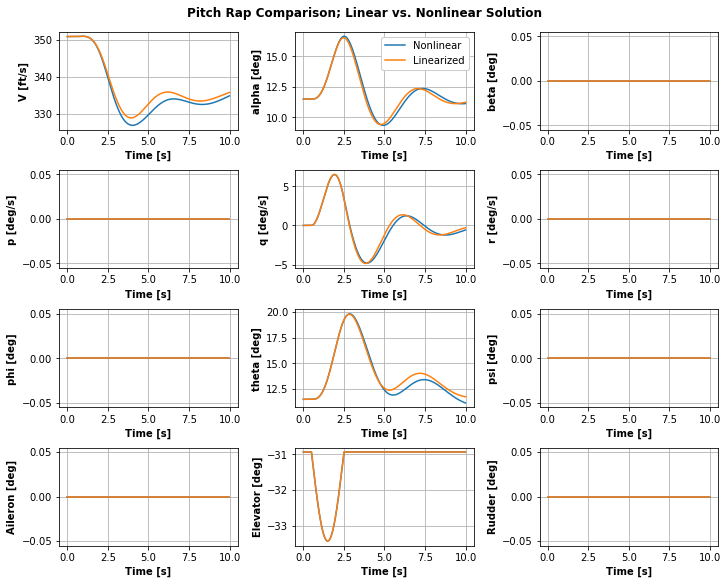

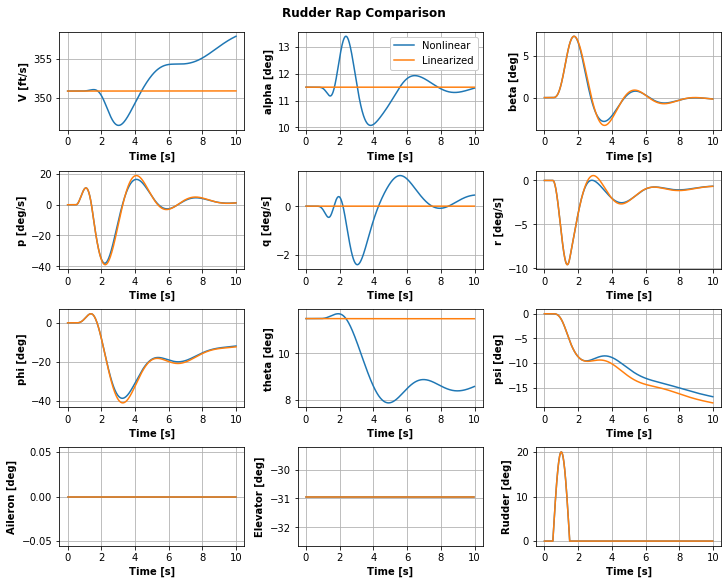

In [10]:

dt = 0.01
T = 10.0
time = np.arange(0, T, dt)
lstyle_nl = '-' 
lstyle_lin = '--'

pitch_start = 0.5
Tpitch = 2.0
dpitch = 2.5/57.3
rudder_start = 0.5
Trudder = 1.0
drudder = 20/57.3

zero = lambda t, x: 0.*t
pitch_trim = lambda t, x: delta0_rad*(t >= 0.)
pitch_rap = lambda t, x: delta0_rad - dpitch*np.sin(np.pi*(t - pitch_start)/Tpitch)*(t > pitch_start)*(t < (pitch_start + Tpitch))
rudder_rap = lambda t, x: drudder*np.sin(np.pi*(t - rudder_start)/Trudder)*(t > rudder_start)*(t < (rudder_start + Trudder))

for (roll_hist, pitch_hist, yaw_hist), title in zip([(zero, pitch_rap, zero),
                                                     (zero, pitch_trim, rudder_rap)], 
                                                    ['Pitch Rap Comparison; Linear vs. Nonlinear Solution',
                                                     'Rudder Rap Comparison']):
    
    f106.set_aero_controls(roll = roll_hist, 
                           pitch = pitch_hist, 
                           yaw = yaw_hist)
    
    eom = lambda t, x: eom_6dof(t, x, f106)
    sol = solve_ivp(eom, [0, T], trim_X0, t_eval = time)
    # u, v, w, p, q, r, phi, theta, psi, Xe, Ye, Ze = sol.y
    outputs_nl = np.array([eom_6dof(ti, yi, f106, output_mode = True) for ti, yi in zip(time, sol.y.T)]).T
    
    U = np.vstack([roll_hist(sol.t, trim_X0), 
                   pitch_hist(sol.t, trim_X0) - pitch_trim(sol.t, trim_X0), 
                   yaw_hist(sol.t, trim_X0)]).T
    
    _, outputs_lin, _ = lsim(linsys, U, sol.t)
    
    outputs_lin += y_0
    
    fig, ax_dict = plt.subplot_mosaic([['V [ft/s]', 'alpha [deg]', 'beta [deg]'],
                                  ['p [deg/s]', 'q [deg/s]', 'r [deg/s]'],
                                  ['phi [deg]', 'theta [deg]', 'psi [deg]'],
                                  ['Aileron [deg]', 'Elevator [deg]', 'Rudder [deg]']],
                                figsize = (10, 8), 
                                constrained_layout = True)
    
    
    for outputs, lstyle, label in zip([outputs_nl, outputs_lin.T], 
                                       [lstyle_nl, lstyle_lin],
                                         ['Nonlinear', 'Linearized']):
        
        V, alpha, beta, p, q, r, phi, theta, psi, xe, ye, ze, ax, ay, az, roll_control, pitch_control, yaw_control = outputs
        ax_dict['V [ft/s]'].plot(sol.t, V, label = label)
        
        ax_dict['alpha [deg]'].plot(sol.t, alpha*RAD_DEG, lstyle_nl, label = label)
        ax_dict['q [deg/s]'].plot(sol.t, q*RAD_DEG, lstyle_nl, label = label)
        ax_dict['theta [deg]'].plot(sol.t, theta*RAD_DEG, lstyle_nl, label = label)
        ax_dict['Elevator [deg]'].plot(sol.t, pitch_control*RAD_DEG, lstyle_nl, label = label)
        
        ax_dict['beta [deg]'].plot(sol.t, beta*RAD_DEG, lstyle_nl, label = label)
        ax_dict['p [deg/s]'].plot(sol.t, p*RAD_DEG, lstyle_nl, label = label)
        ax_dict['r [deg/s]'].plot(sol.t, r*RAD_DEG, lstyle_nl, label = label)
        ax_dict['phi [deg]'].plot(sol.t, phi*RAD_DEG, lstyle_nl, label = label)
        ax_dict['psi [deg]'].plot(sol.t, psi*RAD_DEG, lstyle_nl, label = label)
        
        ax_dict['Aileron [deg]'].plot(sol.t, roll_control*RAD_DEG, lstyle_nl, label = label)
        ax_dict['Rudder [deg]'].plot(sol.t, yaw_control*RAD_DEG, lstyle_nl, label = label)

    ax_dict['alpha [deg]'].legend(loc = 'upper right', framealpha = 1.)
    for key, a in ax_dict.items():
        a.set_xlabel('Time [s]', fontweight = 'bold')
        a.set_ylabel(key, fontweight = 'bold')
        a.grid()
    
    fig.suptitle(title, fontweight = 'bold')

Agreement for the initial transient is quite good, especially for the pitch rap case. The longitudinal elevator excitation causes essentially no effect on sideslip, roll rate/angle, or yaw rate/angle. For the rudder rap, agreement between linear and nonlinear is excellent for the sideslip angle, roll rate/angle, and yaw rate/angle. However there are definite changes in airspeed, angle of attack, and pitch rate/angle that the linear model does not pick up. Note this is for a maneuver that ammounts to a 40 degree change in roll angle -- is 40 degrees a "small angle"? We will revisit this question in detail later, but for now we can see that:

- The linearized model does provide a good representation of the pitch response to a pitch input, and the roll/yaw response to a yaw input
- In this scenario, the roll/yaw response to a pitch input is negligible
- In this scenario, the pitch response to a yaw input is non-neglible, and is worth thinking about in more detail later

(Of course none of this is surprising to anyone who's taken an elementary flight dynamics course, but this is an alternate way to show it before we start diving into the analysis!)

Two other items are worth demonstrating before getting back into the math. First, the eigenvalues of the resulting system are of interest. A detailed discussion of these will follow, but for now I'll print a table and plot on the imaginary pane below. We can all nonzero eigenvalues (or "poles" if you are of the controls inclination) are stable, with 3 complex pairs, one of which close to the origin (low-frequency) and the others located further out (higher frequency). There are also 2 real eigenvalues, both stable, one of which is close to the origin (decays slowly) and one of which is further out (decays quickly). Finally there are four zero eigenvalues, indicating they are neutrally stable and will drift uncorrected if perturbed.

0j
0j
0j
0j
(-0.3824715802162527+1.369935496827243j)
(-0.3824715802162527-1.369935496827243j)
(-0.037748694583569026+0.12017866957018458j)
(-0.037748694583569026-0.12017866957018458j)
(-0.5084020515078707+1.7681798002934255j)
(-0.5084020515078707-1.7681798002934255j)
(-1.4903450996806618+0j)
(-0.13533892703661615+0j)


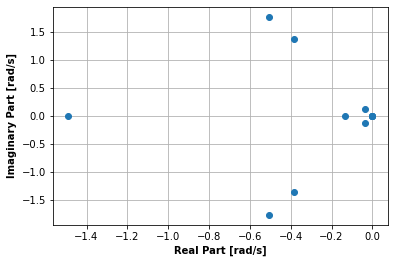

In [11]:

eigvals = np.linalg.eigvals(linsys.A)

fig, ax = plt.subplots(1, 1)

ax.plot(np.real(eigvals), np.imag(eigvals), 'o')
ax.grid()

ax.set_xlabel('Real Part [rad/s]', fontweight = 'bold')
ax.set_ylabel('Imaginary Part [rad/s]', fontweight = 'bold')

for eigval in eigvals:
    print(eigval)


Finally we'll take a look at where the nonzero entries of the linear state transition matrix $\mathbf{A}$ exist. As we can see below there is a clear checkerboard pattern when entries are in their default ordering, which indicates that many variables **do not** couple into others -- for example, a change in $v$ does not affect $u$ and vice versa. There is some dependence on the precision threshold, which gets back into the question of "how small is small" that we will revisit shortly. For now, it's time to get back into the analysis and work through the process of deriving our small disturbance equations.

Text(0.5, 1.0, 'Linearized Flight Dynamics Sparsity Pattern')

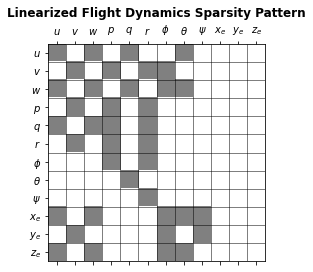

In [12]:

import matplotlib.ticker as tck

# order = [0, 2, 4, 7, 1, 3, 5, 6, 8, 9, 10, 11] # for later

fig, ax = plt.subplots(1, 1)
plt.spy(linsys.A, precision = 1E-6, alpha = 0.5)

ax.set_xticks(range(12))
ax.set_xticklabels(['$u$', '$v$', '$w$', '$p$', '$q$', '$r$', r'$\phi$', r'$\theta$', r'$\psi$', '$x_e$', '$y_e$', '$z_e$'])

ax.set_yticks(range(12))
ax.set_yticklabels(['$u$', '$v$', '$w$', '$p$', '$q$', '$r$', r'$\phi$', r'$\theta$', r'$\psi$', '$x_e$', '$y_e$', '$z_e$'])

# Manually put a grid onto the half-ticks (couldn't get minor grid to work)
xl = ax.get_xlim()
yl = ax.get_ylim()

for di in np.arange(0.5, 12, 1.0):

    ax.hlines(di, *xl, 'k', linewidth = 1.0, alpha = 0.5)
    ax.vlines(di, *yl, 'k', linewidth = 1.0, alpha = 0.5)

ax.set_xlim(xl)
ax.set_ylim(yl)

ax.set_title('Linearized Flight Dynamics Sparsity Pattern', fontweight = 'bold')

### Developing Assumptions for Linearization

The full nonlinear equations we derived previously (with wind and gyroscopic forces neglected, I'll add these at some point) can be broken into four groups; the translational equations are:

$$
\dot{u} = rv - qw - g\sin\theta + (q_\infty S_{ref} C_x + T_x)/m
$$
$$
\dot{v} = pw - ru + g\cos\theta\sin\phi + (q_\infty S_{ref} C_y)/m
$$
$$
\dot{w} = qu - pv + g\cos\theta\cos\phi + (q_\infty S_{ref} C_z + T_z)/m
$$

The rigid body rotational equations are:

$$
\dot{p}I_x - \dot{r}I_{xz} = q_\infty S_{ref}b_{ref}C_\ell - qr(I_z - I_y) + qpI_{xz}
$$
$$
\dot{q}I_y = q_\infty S_{ref} c_{ref}C_m - pr(I_x - I_z) - (p^2 - r^2)I_{xz}
$$
$$
\dot{r}I_z - \dot{p}I_{xz} = q_\infty S_{ref} b_{ref} C_n - pq(I_y - I_x) - qrI_{xz}
$$

The rotational kinematics are:

$$
\dot{\phi} = p + \tan\theta(q\sin\phi + r\cos\phi)
$$
$$
\dot{\theta} = q\cos\phi - r\sin\phi
$$
$$
\dot{\psi} = \dfrac{q\sin\phi + r\cos\phi}{\cos\theta}
$$

And the translational kinematics are:

$$
\dot{X}_E = u\cos\psi\cos\theta + v(\cos\psi\sin\theta\sin\phi - \sin\psi \cos\phi) + w(\cos\psi\sin\theta\cos\phi + \sin\psi\sin\phi)
$$
$$
\dot{Y}_E = u\sin\psi\cos\theta + v(\sin\psi\sin\theta\sin\phi + \cos\psi\cos\phi) + w(\sin\psi\sin\theta\cos\phi - \cos\psi\sin\phi)
$$
$$
\dot{Z}_E = -u\sin\theta + v\cos\theta\sin\phi + w\cos\phi\cos\theta
$$

The basic steps we have to follow to perform the linearization are:

**(1) Specify Generic Simplifying Assumptions**. We are currently assuming:

- A symmetric aircraft about the $y$-plane, such that the inertia terms $I_{xy} = I_{yz} = 0$. $I_{xz}$ can still be nonzero in general
- Effects of wind and rotating machinery are neglected

**(2) Specify a trim state**. We'll start with the level-flight scenario and consider others in follow-on work. This means that in our $\mathbf{x}_0$ vector all initial rates are zero, initial sideslip angle is zero, and initial roll angle is zero. Nonzero quantities are the airspeed, pitch angle, heading angle, and Earth-fixed coordinates. We will also allow a nonzero initial flight path angle $\gamma_0$, where in level flight $\theta_0 = \alpha_0 + \gamma_0$. 

**(3) Specify a reference axis**. While we are required to use a "body-fixed" frame, the *alignment* of that frame is up to us. We have three main choices: 

- For the 6DOF analysis we used a frame aligned with the body reference axis. There is no change to the axis based on flight condition or aircraft weight & balance. This approach is used by Garza & Morelli. If we keep this analysis frame for the linearization:
  - We must use aerodynamic coefficients referenced to the body frame, with no additional transformation required. Since our 6DOF is already using this frame, that means we can use the same coefficients as the 6DOF, which is a benefit.
  - Our initial velocity vector with respect to the analysis frame is $\mathbf{V} = [u_0, 0, w_0] = V_{TAS}[\cos(\alpha_0), 0, \sin(\alpha_0)]$; so we have a nonzero $w_0$ term to carry.
  - We do not need to transform our inertias out of the primary body axis based on flight condition or weight and balance (they can still vary with weight & balance due to the mass property changes)
  - We will carry a nonzero $I_{xz}$ term, that does not vary with flight condition (it still varies with weigth & balance due to the mass property changes)
    
- "Stability-frame." This has the X-axis aligned with the relative wind, rotated by the initial angle of attack $\alpha_0$ from the body reference axis. *This is by far the most common approach used in textbooks*. If we ues this reference for the linearization:
  - We must use aerodynamic coefficients referenced to the stability axis. It may be the case that our aero database was built in the windframe and transformed to the body frame, so maybe this doesn't matter. But in general it does mean we are using a transformation that is different from the body-aligned 6DOF.
  - Our initial velocity vector with respect to the analysis frame is  $\mathbf{V} = [u_0, 0, 0] = [V{TAS}, 0, 0]$; the non-zero $w_0$ term dissapears, which slightly simplifies the equations
  - We must transform our inertias from the primary body axis to the stability axis based on flight condition
  - We will carry a nonzero $I_{xz}$ term, which will vary with flight condition due to the axis transformation
    
- "Principal-Frame." This analysis frame is aligned with the principal axes (assumed symmetric about the $y$-plane). The X-axis is rotated from the body reference frame by an angle $\epsilon$. I believe I have seen this used in one example but can't currently find it. If we use this reference for the linearization:
  - We must transform aerodynamic coefficients from the body frame (or windframe) to the principal frame based on current weight and balance.
  - Our initial velocity vector with respect to the analysis frame is $\mathbf{V} = [u_0, 0, w_0] = V_{TAS}[\cos(\alpha_0 + \epsilon), 0, \sin(\alpha_0 + \epsilon)]$; so we have a nonzero $w_0$ term to carry that is a function of aircraft weight and balance
  - We will be able to use $I_{xz} = 0$ to simplify the equations

As a first pass, **we will use the basic body-frame reference axis**. The simplification provided by using stability axes is quite small, and the benefits of using stability-frame vs. body-frame data are not apparent to me (I think it mostly comes down to past precedent). When comparing linearized to 6DOF results, using a consistent reference frame is extremely helpful. The principal-frame representation may be of interest later when examining certain response features, but we will not carry it forward for now.

With all that in mind, our initial state is 

$$
u_0 = V_{TAS}\cos(\alpha_0)
$$
$$
w_0 = V_{TAS}\sin(\alpha_0)
$$
$$
\theta_0 = \alpha_0 + \gamma_0
$$
$$
v_0 = p_0 = q_0 = r_0 = \phi_0 = 0
$$

Additionally the terms $\psi_0, X_{e0}, Y_{e0}$, and $Z_{e0}$ have arbitrary initial nonzero value. It saves considerable algebra to set $\psi_0 = 0$ for linear analysis and assume that the aircraft is initially travelling in the $X_E$ direction; this can be rectified after the fact if needed. For the linearization, we again carry the $\Delta$ nomenclature for all "perturbation" terms (Etkin carries it for only the terms that are initially nonzero; we will use it for everything) such that

$$
u(t) = u_0 + \Delta u(t)
$$
$$
v(t) = \Delta v(t)
$$

Finally, our relevant control inputs are $\delta_{roll}$, $\delta_{pitch}$, and $\delta_{yaw}$ to denote generic effort about the roll, pitch, and yaw axes, and $\delta_{throttle}$ to denote throttle actuation. The $\delta$ term here indicates "deflection" rather than "small quantity." Following the convention above, the controls are

$$
\delta_{roll}(t) = \Delta\delta_{roll}(t)
$$
$$
\delta_{pitch}(t) = \delta_{pitch, 0} + \Delta\delta_{pitch}(t)
$$
$$
\delta_{yaw}(t) = \Delta\delta_{yaw}(t)
$$
$$
\delta_{throttle}(t) = \delta_{throttle, 0} + \Delta\delta_{throttle}(t)
$$

We can now begin the analysis. The actual method I'll use is based on explictly writing out the $\Delta$ perturbation terms above into the equations, and retaining the terms that fall out of our simplifications. This requires expansion and simplification of the 12 sets of equations. An alternate, and somewhat simpler, approach would be to take partial derivatives of each equation with respect to each variable. The downside of this is that we must take 12 partial derivatives of 12 equations, although obviously many of the derivatives with respect to each variable are zero. Perhaps I'll work through that as an alternate method someday, but for now the "perturbation" approach is below.


## Deriving the Linearization

We'll begin with the translational equations. For each equation, we'll work through with the new "perturbed" expressions for each variable to arrive at its simplified form. I'll also explicitly write out the variables that we assume aerodynamics and thrust depend on; the justification for this is out of scope here so I'll just state the assumptions and leave it at that. In several cases I'll leave out dependencies that could exist in practice but are out of scope for our consideration here.

### Translational Equations

These contain both trigonemetric functions and aerodynamic relations. Fortunately they turn out to be uncoupled between the axes.

#### $\Delta\dot{u}$ Equation

$$
\Delta\dot{u} = \Delta r\Delta v - \Delta q(w_0 + \Delta w) - g\sin(\theta_0 + \Delta\theta) + \left[q_\infty(u_0 + \Delta u) S_{ref} C_x(u_0 + \Delta u, w_0 + \Delta w, \delta_{pitch,0} + \Delta \delta_{pitch}) + T_x(u_0 + \Delta u, \Delta_{throttle,0} + \Delta \delta_{throttle})\right]/m
$$

To simplify:
- Any products of small terms ($\Delta r \Delta v$ for example) are treated as neglible for the linearization
- We can use an identity $\sin(\theta_0 + \Delta\theta) = \sin(\theta_0)\cos(\Delta\theta) +  \sin(\Delta\theta)\cos(\theta_0) \approx \sin(\theta_0) + \Delta\theta\cos(\theta_0)$
- Using the density/airspeed for for dynamic pressure; $q_\infty(u_0 + \Delta u) = \rho_\infty(u_0 + \Delta u)^2/2 = \rho_\infty(u_0^2 + 2u_0\Delta u + \Delta u^2)/2\approx q_\infty(u_0) + 2 q_\infty/u_0 \Delta u$
- $C_x(u_0 + \Delta u, w_0 + \Delta w, \delta_{pitch,0} + \Delta \delta_{pitch}) \approx C_x(u_0, w_0) + C_{x_u} \Delta u + C_{x_{\alpha}} V_{TAS} \Delta w + C_{x,\delta_{pitch}} \Delta \delta_{pitch}$
  - $C_{x_\alpha}$ is used in place of $C_{x_w}$ since we express aerodynamic quantities in terms of the angles
  - The relation between $\alpha$ and $w$ uses $\sin(\Delta\alpha) = \Delta w/V_{TAS}$ so that $\Delta w \approx V_{TAS} \Delta \alpha$
  - The coefficient relation is $C_{x_w} = C_{x_{\alpha}}/V_{TAS}$
- $T_x(u_0 + \Delta u, \Delta_{throttle,0} + \Delta \delta_{throttle}) \approx T_x(u_0, \Delta_{throttle,0}) + T_{x_u} \Delta u + T_{x,\delta_{throttle}} \Delta\delta_{throttle}$

This leaves us with an expression that doesn't quite fit on the page:

$$
\Delta\dot{u} = -\Delta q w_0 - g\left[\sin(\theta_0) + \cos(\theta_0)\Delta\theta_0\right] + \left\{q_\infty S_{ref}\left[C_x(u_0, w_0) + C_{x_u} \Delta u + C_{x_{\alpha}}\Delta w/V_{TAS} + C_{x,\delta_{pitch}} \Delta \delta_{pitch}\right] + 2q_\infty/u_0 S_{ref}C_x(u_0, w_0)\Delta u + T_x(u_0, \Delta_{throttle,0}) + T_{x_u} \Delta u + T_{x,\delta_{throttle}} \Delta\delta_{throttle}\right\}/m
$$

With all that written out, note that by definition of the initial trim state, $\dot{u}(\mathbf{x}_0) = 0$, so

$$
0 = -g\sin(\theta_0) + q_\infty S_{ref} C_x(u_0, w_0) + T_x(u_0, \Delta_{throttle,0})
$$

And the final linearized form is

$$
\Delta\dot{u} =- w_0\Delta q  -g\cos(\theta_0)\Delta\theta  + \big\{q_\infty S_{ref}\left[C_{x_u} \Delta u + C_{x_{\alpha}}  \Delta w /V_{TAS} + C_{x,\delta_{pitch}} \Delta \delta_{pitch}\right] 
$$
$$
+ 2q_\infty/u_0 S_{ref}C_x(u_0, w_0)\Delta u + T_{x_u} \Delta u + T_{x,\delta_{throttle}} \Delta\delta_{throttle}\big\}/m
$$



#### $\Delta \dot{v}$ Equation

$$
\Delta\dot{v} = \Delta p(w_0 + \Delta w) - \Delta r(u_0 + \delta u) + g\cos(\theta_0 + \Delta \theta)\sin(\Delta\phi) + q_\infty S_{ref} C_y(\Delta v, \Delta \delta_{aileron}, \Delta \delta_{roll})/m
$$

Additional simplifications are:
- Using the identify $\cos(\theta_0 + \Delta \theta) = \cos(\theta_0)\cos(\Delta \theta) - \sin(\theta_0)\sin(\Delta\theta) \approx \cos(\theta_0) - \sin(\theta_0)\Delta\theta$
- $ C_y(\Delta v, \Delta \delta_{aileron}, \Delta \delta_{roll}) \approx C_{y_\beta}V_{TAS}\Delta v + C_{y,\delta_{aileron}}\Delta \delta_{aileron} + C_{y,\delta_{rudder}}\Delta \delta_{rudder}$
- Since $C_y = 0$ at the trim state, the differential of $q_\infty$ with respect to $\Delta u$ will not come into play and can be ignored

Leading to 

$$
\Delta\dot{v} = w_0 \Delta p - u_0\Delta r + g\cos(\theta_0)\Delta\phi +  q_\infty S_{ref}(C_{y_\beta}\Delta v/V_{TAS} + C_{y,\delta_{aileron}}\Delta \delta_{aileron} + C_{y,\delta_{rudder}}\Delta \delta_{rudder})/m
$$

In both this equation and the $\Delta \dot{u}$ equation above, the presence of a nonzero $w_0$ is the only price we pay for using an axis system not aligned with the initial airspeed vector.

#### $\Delta \dot{w}$ Equation

$$
\Delta\dot{w} = \Delta q(u_0 + \Delta u) - \Delta p\Delta v + g\cos(\theta_0 + \Delta \theta)\cos(\Delta\phi) + [q_\infty(u_0 + \Delta u) S_{ref} C_z(u_0 + \Delta u, w_0 + \Delta w, \delta_{pitch,0} + \Delta \delta_{pitch}) + T_z(u_0 + \Delta u, \Delta_{throttle,0} + \Delta \delta_{throttle})]/m
$$

This is similar to the $\Delta \dot{u}$ equation, except for the identity $\cos(\theta_0 + \Delta \theta) = \cos(\theta_0)\cos(\Delta \theta) - \sin(\theta_0)\sin(\Delta\theta) \approx \cos(\theta_0) - \sin(\theta_0)\Delta\theta$ which we used for $\dot{v}$. The result of this identity is $g\cos(\Delta\phi)[\cos(\theta_0) - \sin(\Delta\theta)]$. Because $\Delta\phi$ is small we say $\cos(\Delta\phi)\approx 1$ and are left with only the $\sin(\Delta\theta) \approx \Delta\theta$ term in the equations, however **I'll call out here that $\Delta\phi$ is usually the first term to stop being "small" in practice**. We saw this above and will return to it later, but will proceed for now with the small-$\Delta\phi$ assumption.

We can also note that at the steady trim state;

$$
\Delta\dot{w}_0 = 0 = g\cos\theta_0 + q_\infty S_{ref} C_z(u_0, w_0) + T_z(u_0, \Delta_{throttle,0})
$$

So this combination of terms can be removed, leading to:

$$
\Delta\dot{w} = u_0 \Delta q - g\sin(\theta_0)\Delta\theta + \left\{q_\infty S_{ref}\left[C_{z_u} \Delta u + C_{z_{\alpha}} \Delta w/V_{TAS} + C_{z,\delta_{pitch}} \Delta \delta_{pitch}\right] + 2q_\infty/u_0 S_{ref}C_z(u_0, w_0)\Delta u + T_{z_u} \Delta u + T_{z,\delta_{throttle}} \Delta\delta_{throttle}\right\}
$$


### Rotational Equations
The rotational equations have no trigonometric identities, but have even more aerodynamic dependencies (I neglected rate terms in the translational equations, it's easy enough to add them in after the fact if needed).

#### $\Delta\dot{p}$ Equation



$$
\Delta\dot{p}I_x - \Delta\dot{r}I_{xz} = q_\infty S_{ref}b_{ref}C_\ell(\Delta v, \Delta p, \Delta r, \Delta \delta_{roll}, \Delta \delta_{yaw}) - \Delta q\Delta r(I_z - I_y) + \Delta q \Delta pI_{xz}
$$

Note the dissapearnce of the cross-coupled $qp$ and $qr$ terms here; coupling of $\dot{p}$ and $r$ through $I_{xz}$ remains on the left-hand side of the equations, however. (This is the major simplifcation that occurs if we can reference a principal axis system such that $I_{xz} = 0$). Expanding out the remaining aerodynamic dependencies results in:

$$
\Delta\dot{p}I_x - \Delta\dot{r}I_{xz} = q_\infty S_{ref}b_{ref}\left[C_{\ell_\beta}\Delta v/V_{TAS} + \hat{C}_{\ell_p} \Delta p + \hat{C}_{\ell_r} \Delta r + C_{\ell,\delta_{roll}}\Delta\delta_{roll} + C_{\ell,\delta_{yaw}}\Delta\delta_{yaw}\right]
$$

I left in intermediate coefficients $\hat{C}_{\ell_p}$ and $\hat{C}_{\ell_r}$, which are dimensionalized versions of the non-dimensional rate derivatives $C_{\ell_p}$ and $C_{\ell_r}$ -- since the rates are in units of rad/s, they carry a unit of 1/s, and a dimensionalization must occur. The characteristic quantity associated with rate derivatives is the airspeed $V_{TAS}$, and the dimension of length associated with the airspeed can be removed using the characteristic length. For the roll and yaw axes, this characteristic length is the reference span $b_{ref}$. By convention, a factor of 2 is also included. Thus $\hat{C}_{\ell_p} = C_{\ell_p}\cdot b_{ref}/(2 V_{TAS})$, $\hat{C}_{\ell_r} = C_{\ell_r}\cdot b_{ref}/(2 V_{TAS})$, and the linearized form of this equation is

$$
\Delta\dot{p}I_x - \Delta\dot{r}I_{xz} = q_\infty S_{ref}b_{ref}\left[C_{\ell_\beta}\Delta v/V_{TAS} + C_{\ell_p}\cdot b_{ref}/(2 V_{TAS}) \Delta p + C_{\ell_r}\cdot b_{ref}/(2 V_{TAS}) \Delta r + C_{\ell,\delta_{roll}}\Delta\delta_{roll} + C_{\ell,\delta_{yaw}}\Delta\delta_{yaw}\right] = L_\Delta
$$


#### $\Delta \dot{q}$ Equation

$$
\Delta\dot{q}I_y = q_\infty S_{ref} c_{ref}C_m(u_0 + \Delta u, w_0 + \Delta w, \Delta q, \delta_{pitch,0} + \Delta \delta_{pitch}) - \Delta p \Delta r(I_x - I_z) - (p^2 - r^2)I_{xz}
$$

We can note upfront that $\dot{q}_0 = 0$ requires $C_m(u_0, w_0, \Delta_{pitch,0}) = 0$, which eliminates the differential dynamic pressure from consideration. (This is not true in general if a thrust moment is considered, but we have no thrust contribution to pitching moment right now). Additionally, the normalizing length for the pitch rate derivative is the reference chord $c_{ref}$. The resulting linearization is:

$$
\Delta\dot{q} = q_\infty S_{ref} c_{ref}\left(C_{m_u}\Delta u + C_{m_\alpha}\Delta w/V_{TAS} + C_{m_q}\cdot c_{ref}/(2 V_{TAS} \Delta q + C_{m,\delta_{pitch}} \Delta_{pitch}\right)/I_y
$$

#### $\Delta\dot{r}$ Equation

The rotational equations have no trigonometric identities, but have even more aerodynamic dependencies (I neglected rate terms in the translational equations, it's easy enough to add them in after the fact if needed).

$$
\Delta\dot{r}I_z - \Delta\dot{p}I_{xz} = q_\infty S_{ref}b_{ref}C_n(\Delta v, \Delta p, \Delta r, \Delta \delta_{aileron}, \Delta \delta_{rudder}) -  \Delta p \Delta q(I_y - I_x) - \Delta q \Delta rI_{xz}
$$

This is substantially similar to the $\Delta\dot{p}$ equation, with a final result of

$$
\Delta\dot{r}I_z - \Delta\dot{p}I_{xz} = q_\infty S_{ref}b_{ref}\left[C_{n_\beta}\Delta v/V_{TAS} + C_{n_p}\cdot b_{ref}/(2 V_{TAS}) \Delta p + C_{n_r}\cdot b_{ref}/(2 V_{TAS}) \Delta r + C_{n,\delta_{aileron}}\Delta\delta_{aileron} + C_{n,\delta_{rudder}}\Delta\delta_{rudder}\right] = N_\Delta
$$

#### Roll & Yaw Rate Cross-Coupling

Before proceeding, we'll deal with the $\Delta \dot{p}$ and $\Delta \dot{r}$ coupling that exists for nonzero $I_{xz}$. Under our linearizing assumptions, these terms are influened by the sideslip velocity $\Delta v$, roll/yaw rates $p$ and $r$, and aileron/rudder inputs $\delta_{aileron}$ and $\delta_{rudder}$. The variation due to each individual differential term is of the form

$$
\begin{bmatrix}
I_{xx} & -I_{xz} \\
-I_{xz} & I_{zz}
\end{bmatrix}
\begin{Bmatrix}
\Delta\dot{p} \\
\Delta\dot{r}
\end{Bmatrix}
=
\begin{Bmatrix}
L_\Delta \\
N_\Delta
\end{Bmatrix}
$$

Taking the analytical inverse of this expression results in

$$
\begin{Bmatrix}
\Delta\dot{p} \\
\Delta\dot{r}
\end{Bmatrix}
=
\dfrac{1}{I_{xx}I_{zz} - I_{xz}^2}
\begin{bmatrix}
I_{zz} & I_{xz} \\
I_{xz} & I_{xx}
\end{bmatrix}
\begin{Bmatrix}
L_\Delta \\
N_\Delta
\end{Bmatrix}
$$

Or

$$
\Delta\dot{p} = \dfrac{I_{zz}L_\Delta + I_{xz}N_\Delta}{I_{xx}I_{zz} - I_{xz}^2}
$$
$$
\Delta\dot{r} = \dfrac{I_{xz}L_\Delta + I_{xx}N_\Delta}{I_{xx}I_{zz} - I_{xz}^2}
$$


This expression is going to be awkward no matter what, but a normalization can help slightly. Ideally we can find a normalization that ties back to useful physical parameters. Ratios of the inertias are typically used to describe the characteristics of an aircraft, with two important ones being:

- The yaw-to-roll ratio $I_{zz}/I_{xx}$. An aircraft with a high yaw/roll inertia is said to be "body-heavy"
- The cross-term to roll ratio $I_{xz}/I_{xx}$. I'm not aware of terminology related to this ratio, but it's something we'll revisit later

This works quite nicely for the roll rate equation:
$$
\Delta\dot{p} = \dfrac{I_{zz}L_\Delta + I_{xz}N_\Delta}{I_{xx}I_{zz} - I_{xz}^2} \cdot\dfrac{1/I_{xx}^2}{1/I_{xx}^2} = \dfrac{1}{I_{xx}} \cdot\dfrac{(I_{zz}/I_{xx})L_\Delta + (I_{xz}/I_{xx})N_\Delta}{(I_{zz}/I_{xx}) - (I_{xz}/I_{xx})^2}
$$

The same approach is a bit awkward for the yaw rate equation since we end up dividing it by $I_{xx}$ which seems unnatural, but I did promise there would be awkwardness. The form can still take advantage of the two ratio definitions:

$$
\Delta\dot{r} = \dfrac{I_{xz}L_\Delta + I_{xx}N_\Delta}{I_{xx}I_{zz} - I_{xz}^2} \cdot\dfrac{1/I_{xx}^2}{1/I_{xx}^2} = \dfrac{1}{I_{xx}} \cdot\dfrac{(I_{xz}/I_{xx})L_\Delta + N_\Delta}{(I_{zz}/I_{xx}) - (I_{xz}/I_{xx})^2}
$$

Although the importance of these terms will wait for later, it's obvious here that a larger $(I_{xz}/I_{xx})$ ratio means more coupling between yaw and roll accelerations. Whether this coupling is beneficial or detrimental depends on the sign of the inertial imbalance. 

It's also fairly straightforward to observe that for $I_{xz} = 0$ these reduce to the expected uncoupled forms:

$$
\Delta\dot{p} = \dfrac{1}{I_{xx}} \cdot\dfrac{(I_{zz}/I_{xx})L_\Delta}{(I_{zz}/I_{xx})} = L_\Delta/I{xx}
$$
$$
\Delta\dot{r} = \dfrac{1}{I_{xx}} \cdot\dfrac{N_\Delta}{(I_{zz}/I_{xx})} = N_\Delta/I_{zz}
$$

Finally, for the expanded form of each expression we'll define the shorthand $\hat{I}_{zz} = I_{zz}/I_{xx}$, $\hat{I}_{xz} = I_{xz}/I_{xx}$, and $\hat{I} = \hat{I}_{zz} - \hat{I}_{xz}^2$:

$$
\Delta\dot{p} = \dfrac{q_\infty S_{ref}b_{ref}}{I_{xx}} \cdot \left\{\frac{\hat{I}_{zz}}{\hat{I}} \left[C_{\ell_\beta}\Delta v/V_{TAS} + C_{\ell_p}\cdot b_{ref}/(2 V_{TAS}) \Delta p + C_{\ell_r}\cdot b_{ref}/(2 V_{TAS}) \Delta r + C_{\ell,\delta_{roll}}\Delta\delta_{roll} + C_{\ell,\delta_{yaw}}\Delta\delta_{yaw}\right] + \frac{\hat{I}_{xz}} {\hat{I}} \left[C_{n_\beta}\Delta v/V_{TAS} + C_{n_p}\cdot b_{ref}/(2 V_{TAS}) \Delta p + C_{n_r}\cdot b_{ref}/(2 V_{TAS}) \Delta r + C_{n,\delta_{aileron}}\Delta\delta_{aileron} + C_{n,\delta_{rudder}}\Delta\delta_{rudder}\right] \right\}
$$

$$
\Delta\dot{r} = \dfrac{q_\infty S_{ref}b_{ref}}{I_{xx}} \left \{\frac{\hat{I}_{xz}}{\hat{I}} \left[C_{\ell_\beta}\Delta v/V_{TAS} + C_{\ell_p}\cdot b_{ref}/(2 V_{TAS}) \Delta p + C_{\ell_r}\cdot b_{ref}/(2 V_{TAS}) \Delta r + C_{\ell,\delta_{roll}}\Delta\delta_{roll} + C_{\ell,\delta_{yaw}}\Delta\delta_{yaw}\right] + \frac{1}{\hat{I}} \left[C_{n_\beta}\Delta v/V_{TAS} + C_{n_p}\cdot b_{ref}/(2 V_{TAS}) \Delta p + C_{n_r}\cdot b_{ref}/(2 V_{TAS}) \Delta r + C_{n,\delta_{aileron}}\Delta\delta_{aileron} + C_{n,\delta_{rudder}}\Delta\delta_{rudder}\right] \right\}
$$

### Rotational Kinematics

These contain a multitude of coupled trigonemetric functions, most of which fall out due to cross-multiplied perturbations. They are also free of aerodynamic force and moment relations.

#### $\Delta\dot{\phi}$ Equation
$$
\Delta\dot{\phi} = \Delta p + \tan(\theta_0 + \Delta\theta)[\Delta q\sin(\Delta\phi) + \Delta r\cos(\Delta\phi)]
$$

Using the sin and cosine identities for $\theta_0 + \Delta\theta$ to replace the tangent term and eliminating all products of small quantities leads to:
$$
\Delta\dot{\phi}=\Delta p + \dfrac{\sin(\theta_0) + \Delta\theta\cos(\theta_0)}{\cos(\theta_0) - \sin(\theta_0)\Delta\theta} \Delta r
$$

There is surely an elegant way to show the $\sin(\theta_0)\Delta\theta$ term in the denominator must disapear, but failing that I will simply argue that it must dissapear if it multiplies $\Delta r$, leaving us with:

$$
\Delta\dot{\phi} = \Delta p + \tan(\theta_0) \Delta r
$$

#### $\Delta \dot\theta$ Equation

$$
\Delta\dot{\theta} = \Delta q\cos(\Delta\phi) - \Delta r\sin (\Delta\phi)
$$

This is straightforward, except to note that the assumption of small $\Delta \phi$ is often the first to break down and can lead to some amount of coupling between pitch angle and roll angle/yaw rate. Beyond that, the linearized expression is:

$$
\Delta\dot{\theta} = \Delta q
$$

#### $\Delta \dot{\psi}$ Equation

$$
\Delta\dot{\psi} = \dfrac{\Delta q\sin(\Delta\phi) + \Delta r\cos(\Delta \phi)}{\cos(\theta_0 + \Delta\theta)}
$$

We end up at a similar position as with the $\Delta \dot{\phi}$ equation here:

$$
\Delta\dot{\psi} =\dfrac{\Delta r}{\cos(\theta_0) - \sin(\theta_0)\Delta\theta}
$$

And argue once more for the $\Delta\theta$ term to drop out in the numerator, leaving us with

$$
\Delta\dot{\psi} = \Delta r/\cos(\theta_0)
$$

### Translational Kinematics

Finally we work through the annoying number of trigonmetric relations in the translational kinematics. At least there are no fractions present this time, so most of the cross-terms fall out by default.

#### $\Delta \dot{X}_E$ Equation

$$
\dot{X}_E = (u_0 + \Delta u)\cos(\Delta\psi)\cos(\theta_0 + \Delta\theta) + \Delta v \left[\cos(\Delta\psi)(\sin\theta_0 + \Delta\theta)\sin(\Delta\phi) - \sin(\Delta\psi) \cos(\Delta\phi)\right]
$$
$$
+\;(w_0 + \Delta w)\left[(\cos(\Delta\psi)\sin(\theta_0 + \Delta\theta)\cos(\Delta\phi) + \sin(\Delta\psi)\sin(\Delta\phi)\right]
$$

Taking this term by term; 

$$
(u_0 + \Delta u)\cos(\Delta\psi)\cos(\theta_0 + \Delta\theta) \approx (u_0 + \Delta u)\left[\cos(\theta_0) - \sin(\theta_0)\Delta\theta\right]
$$
$$
\approx u_0 \cos(\theta_0) - u_0 \sin(\theta_0)\Delta\theta + \cos(\theta_0) \Delta u 
$$
For the $v$ contribution;
$$
\Delta v \left[\cos(\Delta\psi)(\sin\theta + \Delta\theta)\sin(\Delta\phi) - \sin(\Delta\psi) \cos(\Delta\phi)\right] \approx \Delta v \left[(\sin(\theta_0) + \Delta\theta\cos(\theta_0))\Delta\phi -\Delta\psi\right] \approx 0 
$$ 

And for the $w$ contribution;

$$
(w_0 + \Delta w)\left[\cos(\Delta\psi)\sin(\theta_0 + \Delta\theta)\cos(\Delta\phi) + \sin(\Delta\psi)\sin(\Delta\phi)\right] \approx (w_0 + \Delta w)\left[\sin(\theta_0) + \Delta\theta\cos(\theta_0)\right]
$$
$$
= w_0\sin(\theta_0) + w_0\cos(\theta_0)\Delta\theta + \sin(\theta_0)\Delta w
$$

The total sum is

$$
\Delta\dot{X}_E =u_0 \cos(\theta_0) +  w_0\sin(\theta_0) + (w_0\cos(\theta_0)- u_0 \sin(\theta_0))\Delta\theta + \cos(\theta_0) \Delta u  +\sin(\theta_0)\Delta w
$$

Note the constant term $u_0 \cos(\theta_0) + w_0 \sin(\theta_0) $ associated with the aircraft's initial forward velocity; this does not strictly fit into the state-space form without adding an added "feed-forward" vector. Since $X_E$ is not usually a primary concern out of linear analysis, this can just be treated as a one-off addition to the linear solution if an evaluation of $X_E$ is needed. Furthermore, at a flight path angle of $\gamma=0$, $\theta_0 = \alpha_0$; using the body-oriented analysis frame, $u_0 = V_{TAS}\cos(\theta_0)$ and $w_0 = V_{TAS}\cos(\theta_0)$. The constant term is thus $u_0 \cos(\theta_0) + w_0 \sin(\theta_0) = V_{TAS}(\cos\theta_0^2 + \sin\theta_0^2) = V_{TAS}$ as expected in the absence of winds.

#### $\Delta \dot{Y}_E$ Equation

$$
\dot{Y}_E = (u_0 + \Delta u)\sin(\Delta\psi)\cos(\theta_0 + \Delta\theta) + \Delta v\left[\sin(\Delta\psi)\sin(\theta_0 + \Delta\theta)\sin(\Delta\phi) + \cos(\Delta\psi)\cos(\Delta\phi)\right]
$$
$$+ (w_0 + \Delta w)\left[\sin(\Delta\psi)\sin(\theta_0 + \Delta\theta)\cos(\Delta\phi) - \cos(\Delta\psi)\sin(\Delta\phi)\right]
$$

For the $u$ contribution we have

$$
(u_0 + \Delta u)\sin(\Delta\psi)\cos(\theta_0 + \Delta\theta) \approx (u_0 + \Delta u)\Delta\psi[\cos(\theta_0) - \sin(\theta_0)\Delta\theta]
$$
$$
= u_0 \cos(\theta_0)\Delta\psi
$$

For $v$;

$$
\Delta v\left[\sin(\Delta\psi)\sin(\theta_0 + \Delta\theta)\sin(\Delta\phi) + \cos(\Delta\psi)\cos(\Delta\phi)\right] \approx \Delta v [\Delta\psi (\sin(\theta_0) + \Delta\theta\cos(\theta_0))\Delta\phi + 1] \approx \Delta v
$$

And for $w$;

$$
(w_0 + \Delta w)\left[\sin(\Delta\psi)\sin(\theta_0 + \Delta\theta)\cos(\Delta\phi) - \cos(\Delta\psi)\sin(\Delta\phi)\right] \approx (w_0 + \Delta w)[\Delta\psi(\sin(\theta_0) + \Delta\theta\cos(\theta_0)) - \Delta\phi] \approx (w_0 + \Delta w)[\Delta\psi\sin(\theta_0) - \Delta\phi]
$$
$$
\approx w_0\sin(\theta_0)\Delta\psi - w_0 \Delta\phi
$$

For a total expression of

$$
\Delta\dot{Y}_E = \Delta v + [u_0 \cos(\theta_0) + w_0\sin(\theta_0)]\Delta\psi - w_0 \Delta\phi
$$

#### $\Delta \dot{Z}_E$ Equation

$$
\Delta\dot{Z}_E = -(u_0 + \Delta u)\sin(\theta_0 + \Delta\theta) + \Delta v\cos(\theta_0 + \Delta\theta)\sin(\Delta\phi) + (w_0 + \Delta w)\cos(\Delta\phi)\cos(\theta_0 + \Delta\theta)
$$

Once more; the $u$ contribution is

$$
 -(u_0 + \Delta u)\sin(\theta_0 + \Delta\theta) \approx  -(u_0 + \Delta u)(\sin(\theta_0) + \Delta\theta\cos(\theta_0)) \approx -u_0\sin(\theta_0) - u_0\cos(\theta_0)\Delta\theta - \sin(\theta_0)\Delta u
$$

The $v$ contribution is 

$$
\Delta v\cos(\theta_0 + \Delta\theta)\sin(\Delta\phi) \approx \Delta v(\cos(\theta_0) - \sin(\theta_0)\Delta\theta)\Delta\phi \approx 0
$$

And the $w$ contribution is

$$
(w_0 + \Delta w)\cos(\Delta\phi)\cos(\theta_0 + \Delta\theta) \approx (w_0 + \Delta w)(\cos(\theta_0) - \sin(\theta_0)\Delta\theta) \approx w_0 \cos(\theta_0) - w_0\sin(\theta_0)\Delta\theta + \cos(\theta_0)\Delta w
$$

For a total contribution of

$$
\Delta\dot{Z}_E = w_0 \cos(\theta_0) -u_0\sin(\theta_0) - [u_0\cos(\theta_0) +  w_0\sin(\theta_0)]\Delta\theta - \sin(\theta_0)\Delta u + \cos(\theta_0)\Delta w
$$

As with the $\Delta\dot{X}_E$ expression there is a constant term; in this case $w_0 \cos(\theta_0) -u_0\sin(\theta_0)$. In this case, for zero flight path angle with $\theta_0 = \alpha_0$, the expression becomes $V_{TAS}\sin(\theta_0)\cos(\theta_0) - V_{TAS}\cos(\theta_0)\sin(\theta_0) = 0$ as expected for the climb rate at zero flight path angle.  

### Assembling the Equations

With the linearizations of each equation complete, we're ready to collect them into a full matrix equation. As a start I'll repeat each equation line-by-line, in order:

$$
\Delta\dot{u} =- w_0\Delta q  -\cos(\theta_0)\Delta\theta  + \big\{q_\infty S_{ref}\left[C_{x_u} \Delta u + C_{x_{\alpha}} \Delta w/V_{TAS} + C_{x,\delta_{pitch}} \Delta \delta_{pitch}\right] 
$$
$$
+ 2q_\infty/u_0 S_{ref}C_x(u_0, w_0)\Delta u + T_{x_u} \Delta u + T_{x,\delta_{throttle}} \Delta\delta_{throttle}\big\}/m
$$

$$
\Delta\dot{v} = w_0 \Delta p - u_0\Delta r + g\cos(\theta_0)\Delta\phi +  q_\infty S_{ref}(C_{y_\beta}\Delta v/V_{TAS} + C_{y,\delta_{aileron}}\Delta \delta_{aileron} + C_{y,\delta_{rudder}}\Delta \delta_{rudder})/m
$$

$$
\Delta\dot{w} = u_0 \Delta q - g\sin(\theta_0)\Delta\theta + \left\{q_\infty S_{ref}\left[C_{z_u} \Delta u + C_{z_{\alpha}} \Delta w/V_{TAS} + C_{z,\delta_{pitch}} \Delta \delta_{pitch}\right] + 2q_\infty/u_0 S_{ref}C_z(u_0, w_0)\Delta u + T_{z_u} \Delta u + T_{z,\delta_{throttle}} \Delta\delta_{throttle}\right\}
$$

$$
\Delta\dot{p} = \dfrac{1}{I_{xx}} \left[\dfrac{\hat{I}_{zz}}{\hat{I}}L_\Delta + \frac{\hat{I}_{xz}}{\hat{I}}M_\Delta \right]
$$

$$
\Delta\dot{q} = q_\infty S_{ref} c_{ref}\left[C_{m_u}\Delta u + C_{m_\alpha}\Delta w/V_{TAS} + C_{m_q}\cdot c_{ref}/(2 V_{TAS}) \Delta q + C_{m,\delta_{pitch}} \Delta\delta_{pitch}\right]/I_y
$$

$$
\Delta\dot{r} = \dfrac{1}{I_{xx}} \left[\dfrac{\hat{I}_{xz}}{\hat{I}}L_\Delta + \frac{1}{\hat{I}}M_\Delta \right]
$$

$$
\Delta\dot{\phi} = \Delta p + \tan(\theta_0) \Delta r
$$

$$
\Delta\dot{\theta} = \Delta q
$$

$$
\Delta\dot{\psi} = \Delta r/\cos(\theta_0)
$$

$$
\Delta\dot{X}_E =u_0 \cos(\theta_0) +  w_0\sin(\theta_0) + (w_0\cos(\theta_0)- u_0 \sin(\theta_0))\Delta\theta + \cos(\theta_0) \Delta u  +\sin(\theta_0)\Delta w
$$

$$
\Delta\dot{Y}_E = \Delta v + [u_0 \cos(\theta_0) + w_0\sin(\theta_0)]\Delta\psi - w_0 \Delta\phi
$$

$$
\Delta\dot{Z}_E = w_0 \cos(\theta_0) -u_0\sin(\theta_0) - [u_0\cos(\theta_0) +  w_0\sin(\theta_0)]\Delta\theta - \sin(\theta_0)\Delta u + \cos(\theta_0)\Delta w
$$


Based on the example above (and the entire published body of work on flight dynamics) we have reason to believe that the speed/AoA/pitch and roll/yaw/sideslip components of the motion decouple from each other. Careful investigation of the equations above confirms this and allow us to write out two decoupled state-space systems with a reordering of variables into two groups:

- "Longitudinal" (speed/AoA/pitch): $u$, $w$, $q$, $\theta$, $X_E$, and $Z_E$, with control inputs $\delta_{pitch}$ and $\delta_{throttle}$
- "Lateral/directional" (roll/yaw/sideslip): $v$, $p$, $r$, $\phi$, $\psi$, $Y_E$, with control inputs $\delta_{aileron}$ and $\delta_{rudder}$. The use of "lateral/directional" is unfortunate since "lateral" means "side to side" but is used to refer to rolling motion. "Directional" refers to the yawing component of the motion. I won't try to change the convention here, just note that it is a bit misleading.

This gives us the decoupled state vectors $\Delta \mathbf{x}_{long}$ and $\Delta \mathbf{x}_{lat}$, each of which is associated with the state space matrices $\mathbf{A}_{long}$, $\mathbf{A}_{lat}$, etc. 


### Longitudinal Linear System

The longitudinal system has states 

$$
\Delta\mathbf{x}_{long} = \Delta[u, w, q, \theta, X_E, Z_E]^T
$$

with a state transition matrix:

$$
\mathbf{A}_{long} =
\begin{bmatrix}
% u & w & q & theta & XE & ZE
q_\infty S_{ref}[C_{x_u} + 2C_x(u_0, w_0)/u_0]/m + T_{x_u}/m &  q_\infty S_{ref}C_{x_{\alpha}}/(mV_{TAS}) & -w_0 & -g\cos\theta_0 & 0 & 0 \\ % u
q_\infty S_{ref}[C_{z_u} + 2C_z(u_0, w_0)/u_0]/m + T_{z_u}/m& q_\infty S_{ref}C_{z_\alpha}/(mV_{TAS}) & u_0 & -g\sin\theta_0 & 0 & 0 \\ % w
q_\infty S_{ref} c_{ref}C_{m_u}/Iy & q_\infty S_{ref} c_{ref}C_{m_{\alpha}}/(I_yV_{TAS}) & q_\infty S_{ref} \frac{c_{ref}^2}{2 V_{TAS}}C_{m_q}/I_y & 0 & 0 & 0 \\ % q
0 & 0 & 1 & 0 & 0 & 0 \\ % theta
\cos\theta_0 & \sin\theta_0 & 0 & -u_0\sin\theta_0 + w_0\cos\theta_0 & 0 & 0 \\ % XE
-\sin\theta_0 & \cos\theta_0 & 0 & -u_0\cos\theta_0 - w_0\sin\theta_0 & 0 & 0\\ % ZE
\end{bmatrix}
$$

Note that the rank of this matrix is obviously only four due to the zero columns for $X_E$ and $Y_E$, which is why most derivations will show the first four variables alone. We'll hold onto $X_E$ and $Z_E$ for the time being and drop them later when appropriate. 

The system inputs are 

$$
\Delta\mathbf{u}_{long} = \Delta [\delta_{pitch}, \delta_{throttle}]^T
$$

and a corresponding input influence matrix:

$$
\mathbf{B}_{long} = 
\begin{bmatrix}
% elevator & throttle
q_\infty S_{ref} C_{x,\delta_{pitch}}/m & T_{x,\delta_{throttle}}/m \\ % u
q_\infty S_{ref} C_{z,\delta_{pitch}}/m & T_{z,\delta_{throttle}}/m \\ % w
q_\infty S_{ref} c_{ref} C_{m,\delta_{pitch}}/I_{yy} & 0 \\ % q
0 & 0 \\
0 & 0 \\
0 & 0 \\
\end{bmatrix}
$$

System outputs can be chosen arbitrarily; for now I'll select the forward airspeed, angle of attack, pitch rate, pitch angle, load factor, and change in altitude:

$$
\mathbf{y}_{long} = \begin{bmatrix}\Delta V_{TAS} & \Delta \alpha & \Delta q & \Delta \theta & \Delta n_z & \Delta h & \Delta\delta_{pitch} \end{bmatrix}
$$

The items that are not direct system states or inputs are the change in airspeed:

$$
\Delta V_{TAS} = \dfrac{u_0}{V_{TAS,0}}\Delta u + \dfrac{w_0}{V_{TAS, 0}} \Delta w
$$

Angle of attack:

$$
\Delta \alpha = \Delta w / V_{TAS,0}
$$

Load factor (in $g$):

$$
\Delta n_z =  \left\{(q_\infty S_{ref}[C_{z_u} + 2C_z(u_0, w_0)/u_0] + T_{z_u})\Delta u + q_\infty S_{ref}C_{z_\alpha}\Delta w/V_{TAS} + q_\infty S_{ref} C_{z,\delta_{pitch}}\Delta\delta_{pitch} + T_{z,\delta_{throttle}}\Delta\delta_{throttle}\right\}/(mg)
$$

And altitude, which we will be converted from "z-down" convention such that a positive quantitity indicates an increase in altitude:

$$
\Delta h = -\Delta Z_E
$$

The corresponding output-state and feedforward matrices are

$$
\mathbf{C}_{long} = 
\begin{bmatrix}
% u & w & q & theta & XE & ZE
\dfrac{u_0}{V_{TAS,0}} & \dfrac{w_0}{V_{TAS,0}} & 0 & 0 & 0 & 0 \\ % V_TAS
0 & \dfrac{1}{V_{TAS,0}} & 0 & 0 & 0 & 0 \\ % Alpha
0 & 0 & 1 & 0 & 0 & 0 \\ % q
0 & 0 & 0 & 1 & 0 & 0 \\ % Theta
q_\infty S_{ref}[C_{z_u} + 2C_z(u_0, w_0)/u_0] + T_{z_u})/(mg) & q_\infty S_{ref}C_{z_\alpha}/(mgV_{TAS,0}) & 0 & 0 & 0 & 0 \\ % nz
0 & 0 & 0 & 0 & 0 & -1 \\  % h 
0 & 0 & 0 & 0 & 0 & 0 % Delta pitch
\end{bmatrix}
$$

$$
\mathbf{D}_{long} = 
\begin{bmatrix}
0 & 0 \\ % V_TAS
0 & 0 \\ % Alpha
0 & 0 \\ % q
0 & 0 \\ % theta
q_\infty S_{ref} C_{z,\delta_{pitch}}/(mg) & T_{z,\delta_{throttle}}/(mg)  \\ % nz
0 & 0 \\ % h
1 & 0 \\ % Delta pitch
\end{bmatrix}
$$

A Python implementation of a function to return the associated state space system is defined below, using the same inputs as the "linearized 6DOF" method at the beginning of this section. The numerical finite difference approach is extensible to more general aerodynamics models (although it would be best to enhance the simple forward difference with a central or higher-order calculation) even though it isn't necessary for the LinearAircraft class which has the aero derivatives defined internally. 

Longitudinal coefficients; stored vs. expected
Cx_u 0 0.0
Cz_u 0 0.0
Cm_u 0 0.0
Cx_a -0.6 -0.6000000000000005
Cz_a -2.8 -2.7999999999999914
Cm_a -0.16 -0.15999999999999903
Cm_q 0.0 0.0
Cx_delta -0.12000000000000002 -0.12000000000000066
Cz_delta -0.56 -0.5600000000000049
Cm_delta -0.3 -0.30000000000000027


Text(0.5, 0.98, '6DOF/Linearized 6DOF/Linear Longitudinal Pitch Rap Comparison')

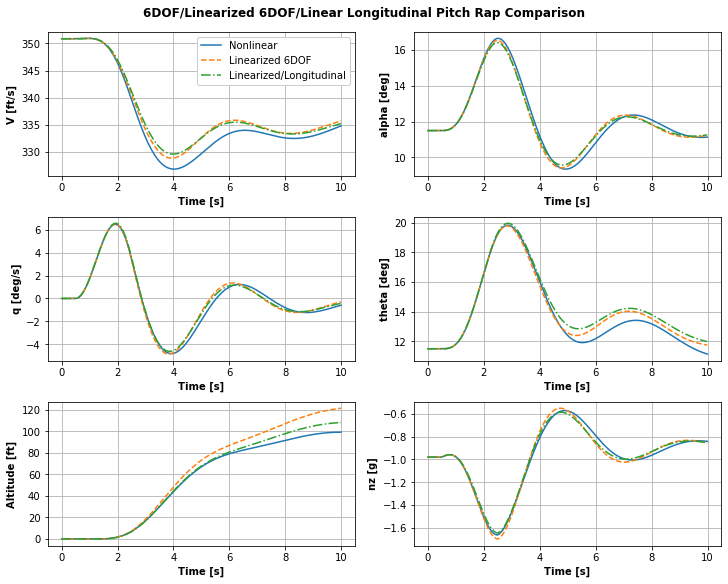

In [14]:


def get_aero_derivatives_long(aircraft, trim_X0, delta_state = 0.01, delta_control = 0.01):
    """
    Obtains the aerodynamic derivatives associated with longitudinal stability 
    & control via finite difference using the supplied aircraft object at specified
    trim conditions. Aircraft must be set at a control setting and throttle level 
    that puts it at or near a valid trim state, or the linearization will be invalid.
    
    Parameters
    ----------
    aircraft : Aircraft
        Aircraft object which implements "get_thrust," "get_mass_props," and 
        "get_aero_coeffs" properties
    airspeed : float
        True airspeed for trim
    trim_X0 : array
        Trim initial conditions for the 6DOF solver
        
    Returns
    -------
    stab_coeffs : array
        Array of stability coeffiicents in the order [Cx_u, Cz_u, Cm_u, Cx_alpha, 
        Cz_alpha, Cm_alpha, Cm_q]
    control_coeffs : array
        Array of control coefficients in the order [Cx_delta_pitch, Cz_delta_pitch, 
        Cm_delta_pitch]
        
    """
    
    # Initialize
    stab_coeffs = list()
    control_coeffs = list()
    roll_0 = aircraft.roll_control
    pitch_0 = aircraft.pitch_control
    yaw_0 = aircraft.yaw_control
    
    # Initial coeffs in order [Cx, Cy, Cz, Cmx, Cmy, Cmz]
    coeff_inds = [0, 2, 4]
    coeffs_0 = np.array(aircraft.get_aero_coeffs(0, trim_X0))[coeff_inds]
    
    # Change due to u at constant alpha
    u0 = trim_X0[0]
    w0 = trim_X0[2]
    VTAS = np.sqrt(u0*u0 + w0*w0)
    alpha0 = np.arcsin(trim_X0[2]/VTAS)
    VTAS1 = VTAS + delta_state
    delta_x = trim_X0.copy()
    delta_x[0] = VTAS1*np.cos(alpha0)
    delta_x[2] = VTAS1*np.sin(alpha0)
    coeffs_du = np.array(aircraft.get_aero_coeffs(0, delta_x))[coeff_inds]
    stab_coeffs.extend((coeffs_du - coeffs_0)/delta_state)
    
    # Change due to w
    delta_x = trim_X0.copy()
    alpha1 = alpha0 + delta_state
    # delta_x[0]
    delta_x[0] = VTAS*np.cos(alpha1)
    delta_x[2] = VTAS*np.sin(alpha1)
    VTAS_new = np.sqrt(sum(delta_x[:2]**2))
    alpha_new = np.arcsin(delta_x[2]/VTAS_new)
    coeffs_da = np.array(aircraft.get_aero_coeffs(0, delta_x))[coeff_inds]
    stab_coeffs.extend((coeffs_da - coeffs_0)/(delta_state))
    
    # Change due to q
    delta_x = trim_X0.copy()
    delta_x[4] += delta_state*2*VTAS/aircraft.cref
    coeffs_dq = np.array(aircraft.get_aero_coeffs(0, delta_x))[4]  # Cm only
    stab_coeffs.append((coeffs_dq - coeffs_0[-1])/delta_state)
    
    # Change due to control input
    aircraft.set_aero_controls(roll = roll_0, 
                               pitch = lambda t, x: pitch_0(t, x) + delta_control,
                               yaw = yaw_0)
    coeffs_dpitch = np.array(aircraft.get_aero_coeffs(0, trim_X0))[coeff_inds]
    control_coeffs.extend((coeffs_dpitch - coeffs_0)/delta_control)
    
    # Reset controls to initial values
    aircraft.set_aero_controls(roll = roll_0, 
                               pitch = pitch_0, 
                               yaw = yaw_0)
    
    return np.array(stab_coeffs), np.array(control_coeffs)
    

# Check stab coeff calculation vs expected
(Cx_u, Cz_u, Cm_u, Cx_alpha, Cz_alpha, Cm_alpha, Cm_q), (Cx_delta, Cz_delta, Cm_delta) = get_aero_derivatives_long(f106, trim_X0)

print('Longitudinal coefficients; stored vs. expected')
print('Cx_u', 0, Cx_u)
print('Cz_u', 0, Cz_u)
print('Cm_u', 0, Cm_u)
print('Cx_a', f106.Cxa, Cx_alpha)
print('Cz_a', f106.Cza, Cz_alpha)
print('Cm_a', f106.Cma, Cm_alpha)
print('Cm_q', f106.Cmq, Cm_q)
print('Cx_delta', f106.Cxdp, Cx_delta)
print('Cz_delta', f106.Czdp, Cz_delta)
print('Cm_delta', f106.Cmdp, Cm_delta)

def get_linearized_long(aircraft, trim_X0, rho = RHO_SL_SLUG_FT3, g = G_FT_S2):
    """
    Obtains linearized state-space matrices for the supplied aircraft object
    at specified airspeed and trim conditions. Aircraft must be set at a control
    setting and throttle level that puts it at or near a valid trim state,
    or the linearization will be invalid

    Parameters
    ----------
    aircraft : Aircraft
        Aircraft object which implements "get_thrust," "get_mass_props," and 
        "get_aero_coeffs" properties
    airspeed : float
        True airspeed for trim
    trim_X0 : array
        Trim initial conditions for the 6DOF solver
    rho : float, optional
        Atmospheric density at trim altitude. Default value is sea level in slug/ft^3
    g : float, optional
        Gravitional acceleration value. Default is sea level value in ft/s^2

    Returns
    -------
    lti_sys : LinearTimeInvariant
        Returns a state-space representation of a linear time invariant system
        obtained by the linearization. States are the 6DOF states, inputs are
        the control inputs, and outputs are the 6DOF outputs
    y_0 : Array
        Vector of linear system outputs at the trim state

    """
    
    # Aerodynamic derivatives
    stab_coeffs, control_coeffs = get_aero_derivatives_long(aircraft, trim_X0)
    Cxu, Czu, Cmu, Cxa, Cza, Cma, Cmq = stab_coeffs
    Cxdp, Czdp, Cmdp = control_coeffs
    
    # Neglect any propulsion derivatives for now
    Txu = 0.
    Tzu = 0.
    Txdt = 0.
    Tzdt = 0.
    
    # Inertial, dynamic pressure, and reference quantities
    mass = aircraft.mass
    Iyy = aircraft.Iyy
    u0 = trim_X0[0]
    w0 = trim_X0[2]
    theta0 = trim_X0[7]
    VTAS = np.sqrt(u0*u0 + w0*w0)
    qinf = 0.5*rho*VTAS**2
    sref = aircraft.sref
    cref = aircraft.cref
    
    # Initial coefficient values where needed
    Cx0, Cz0, _ = np.array(aircraft.get_aero_coeffs(0, trim_X0))[[0, 2, 4]]
    
    # A matrix definition (state transition)
    A = np.array([[qinf*sref*(Cxu + 2*Cx0/u0)/mass + Txu/mass, 
                   qinf*sref*Cxa/(VTAS*mass), -w0, -g*np.cos(theta0), 0., 0.], # u
                  [qinf*sref*(Czu + 2*Cz0/u0)/mass + Tzu/mass, 
                  qinf*sref*Cza/(VTAS*mass), u0, -g*np.sin(theta0), 0., 0.], # w
                  [qinf*sref*cref*Cmu/Iyy, qinf*sref*cref*Cma/(VTAS*Iyy), 
                  qinf*sref*cref**2/(2*VTAS)*Cmq, 0., 0., 0.], # q
                  [0., 0., 1., 0., 0., 0.], # theta
                  [np.cos(theta0), np.sin(theta0), 0., -u0*np.sin(theta0) + w0*np.cos(theta0), 0., 0.], # XE
                  [-np.sin(theta0), np.cos(theta0), 0., -u0*np.cos(theta0) - w0*np.sin(theta0), 0., 0.], # YE
                 ])
    
    # B matrix definition (input influence)
    B = np.array([[qinf*sref*Cxdp/mass, Txdt/mass], # u 
                  [qinf*sref*Czdp/mass, Tzdt/mass], # w
                  [qinf*sref*cref*Cmdp/Iyy, 0.],   # q
                  [0., 0.,],   # theta
                  [0., 0.,],   # XE 
                  [0., 0.,]])  # ZE
    
    # C matrix definition (state output)
    C = np.array([[u0/VTAS, w0/VTAS, 0., 0., 0., 0.], # VTAS
                  [0., 1/VTAS, 0., 0., 0., 0.],  # Alpha
                  [0., 0., 1., 0., 0., 0.],  # q
                  [0., 0., 0., 1., 0., 0.],  # theta
                  [(qinf*sref*(Czu + 2*Cz0/u0) + Tzu)/(mass*g), 
                  qinf*sref*Cza/(mass*g*VTAS), 0., 0., 0., 0.],  # nz
                  [0., 0., 0., 0., 0., -1.],  # h
                  [0., 0., 0., 0., 0., 0.]]) # Delta pitch
    
    # D matrix definition (input feed-forward)
    D = np.array([[0., 0.], 
                  [0., 0.],
                  [0., 0.],
                  [0., 0.],
                  [qinf*sref*Czdp/(mass*g), Tzdt/(mass*g)],
                  [0., 0.],
                  [1., 0.]])
    
    

    # Initial output values from indexed 6DOF EOM outputs
    # V, alpha, beta, [*0*, *1*, 2,
    # p, q, r,         3, *4*, 5,
    # phi, theta, psi, 6, *7*, 8
    # xe, ye, ze,      9, 10, *11*,
    # ax, ay, az,      12, 13, *14*, 
    # roll_control, pitch_control, yaw_control    15, *16*, 17]
    y_0 = eom_6dof(0., trim_X0, aircraft, output_mode = True)[[0, 1, 4, 7, 14, 11, 16]]
    
    return lti(A, B, C, D), y_0

# Checkout of linearization against previous results
linsys_long, y_0_long = get_linearized_long(f106, trim_X0)

# print(np.linalg.eigvals(linsys_long.A))
# print(linsys_long.A)

long_coeffs = [0, 2, 4, 7, 9, 11]
A_check = np.array([s[long_coeffs] for s in linsys.A[long_coeffs]])

# Run simulation
roll_hist = lambda t, x: 0.
yaw_hist = lambda t, x: 0.
f106.set_aero_controls(roll = zero, 
                       pitch = pitch_rap, 
                       yaw = zero)
    
eom = lambda t, x: eom_6dof(t, x, f106)
sol = solve_ivp(eom, [0, T], trim_X0, t_eval = time)
# u, v, w, p, q, r, phi, theta, psi, Xe, Ye, Ze = sol.y
outputs_nl = np.array([eom_6dof(ti, yi, f106, output_mode = True) for ti, yi in zip(time, sol.y.T)]).T

U = np.vstack([zero(sol.t, trim_X0), 
               pitch_rap(sol.t, trim_X0) - pitch_trim(sol.t, trim_X0), 
               zero(sol.t, trim_X0)]).T

# Numerical linear system
_, outputs_lin, _ = lsim(linsys, U, sol.t)
outputs_lin += y_0

# Explictly written longitudinal system
U = np.vstack([pitch_rap(sol.t, trim_X0) - pitch_trim(sol.t, trim_X0),
                zero(sol.t, trim_X0)]).T
_, outputs_lin_long, _ = lsim(linsys_long, U, sol.t)
outputs_lin_long += y_0_long

fig, ax_dict = plt.subplot_mosaic([['V [ft/s]', 'alpha [deg]'],
                                  ['q [deg/s]', 'theta [deg]'],
                                  ['Altitude [ft]', 'nz [g]']],
                                figsize = (10, 8), 
                                constrained_layout = True)


for outputs, lstyle, label in zip([outputs_nl, outputs_lin.T, outputs_lin_long.T], 
                                   [lstyle_nl, lstyle_lin, '-.'],
                                     ['Nonlinear', 'Linearized 6DOF', 'Linearized/Longitudinal']):
    try:
        V, alpha, beta, p, q, r, phi, theta, psi, xe, ye, ze, ax, ay, az, roll_control, pitch_control, yaw_control = outputs
        ax_dict['V [ft/s]'].plot(sol.t, V, lstyle, label = label)

        ax_dict['alpha [deg]'].plot(sol.t, alpha*RAD_DEG, lstyle, label = label)
        ax_dict['q [deg/s]'].plot(sol.t, q*RAD_DEG, lstyle, label = label)
        ax_dict['theta [deg]'].plot(sol.t, theta*RAD_DEG, lstyle, label = label)
        ax_dict['nz [g]'].plot(sol.t, az, lstyle, label = label)
        ax_dict['Altitude [ft]'].plot(sol.t, -ze, lstyle, label = label)

        
    except:
        V, alpha, q, theta, nz, h, pitch_control = outputs
        ax_dict['V [ft/s]'].plot(sol.t, V, lstyle, label = label)

        ax_dict['alpha [deg]'].plot(sol.t, alpha*RAD_DEG, lstyle, label = label)
        ax_dict['q [deg/s]'].plot(sol.t, q*RAD_DEG, lstyle, label = label)
        ax_dict['theta [deg]'].plot(sol.t, theta*RAD_DEG, lstyle, label = label)
        ax_dict['nz [g]'].plot(sol.t, nz, lstyle, label = label)
        ax_dict['Altitude [ft]'].plot(sol.t, h, lstyle, label = label)


ax_dict['V [ft/s]'].legend(loc = 'upper right', framealpha = 1.)
for key, a in ax_dict.items():
    a.set_xlabel('Time [s]', fontweight = 'bold')
    a.set_ylabel(key, fontweight = 'bold')
    a.grid()

fig.suptitle('6DOF/Linearized 6DOF/Linear Longitudinal Pitch Rap Comparison', fontweight = 'bold')



The explicit longitudinal linearization matches well with the numerical 6DOF linearization, although some differences are visible, particularly in the altitude state. We will consider this level of agreement acceptable and move on to the lateral/directional linearization. 

### Lateral/Directional Linear System

The lateral/directional states are
$$
\Delta\mathbf{x}_{lat} = \Delta[v, p, r, \phi, \psi, Y_E]^T
$$

With an associated state transition matrix of

$$
\mathbf{A}_{lat}=
\begin{bmatrix}
% v & p & r & phi & psi & YE
q_\infty S_{ref} C_{y_{\beta}}/(mV_{TAS}) & w_0 & -u_0 & g\cos\theta_0 & 0 & 0 \\  % v
\bar{Q}/(I_{xx}V_{TAS})\left[\frac{\hat{I}_{zz}}{\hat{I}}C_{\ell_\beta} + \frac{\hat{I}_{xz}}{\hat{I}}C_{n_\beta} \right] & \bar{Q}
\frac{b_{ref}}{2I_{xx}V_{TAS}}\left[\frac{\hat{I}_{zz}}{\hat{I}}C_{\ell_p} + \frac{\hat{I}_{xz}}{\hat{I}}C_{n_p} \right] & \bar{Q}\frac{b_{ref}}{2I_{xx}V_{TAS}}\left[\frac{\hat{I}_{zz}}{\hat{I}}C_{\ell_r} + \frac{\hat{I}_{xz}}{\hat{I}}C_{n_r} \right] & 0 & 0 & 0 \\  % p
\bar{Q}/(I_{xx}V_{TAS})\left[\frac{\hat{I}_{xz}}{\hat{I}}C_{\ell_\beta} + \frac{1}{\hat{I}}C_{n_\beta} \right] & \bar{Q}
\frac{b_{ref}}{2I_{xx}V_{TAS}}\left[\frac{\hat{I}_{xz}}{\hat{I}}C_{\ell_p} + \frac{1}{\hat{I}}C_{n_p} \right] & \bar{Q}\frac{b_{ref}}{2I_{xx}V_{TAS}}\left[\frac{\hat{I}_{xz}}{\hat{I}}C_{\ell_r} + \frac{1}{\hat{I}}C_{n_r} \right] & 0 & 0 & 0 \\  % r 
0 & 1 & \tan(\theta_0) & 0 & 0 & 0 \\
0 & 0 & \frac{1}{\cos(\theta_0)} & 0 & 0 & 0 \\
1 & 0 & 0 & -w_0 & u_0 \cos(\theta_0) + w_0\sin(\theta_0) & 0 \\
\end{bmatrix}
$$

Where the shorthand normalization term $\bar{Q}=q_\infty S_{ref} b_{ref}/I_{xx}$ has been introduced for the rotational terms. Unlike the longitudinal case, this matrix has a rank of 5. However it still produces two zero-valued eigenvalues as we will confirm at the end of this section. 

The lateral/directional input vector is

$$
\Delta\mathbf{u}_{lat} =\Delta[\delta_{aileron}, \delta_{rudder}]^T
$$

$$
\mathbf{B}_{lat} = 
\begin{bmatrix}
% aileron & rudder
q_\infty S_{ref} C_{y,\delta_{aileron}}/m & q_\infty S_{ref} C_{y,\delta_{rudder}}/m \\ % v
\bar{Q}/I_{xx}\left[\frac{\hat{I}_{zz}}{\hat{I}}C_{\ell,\delta_{aileron}} + \frac{\hat{I}_{xz}}{\hat{I}}C_{n,\delta_{aileron}} \right] & \bar{Q}/I_{xx}\left[\frac{\hat{I}_{zz}}{\hat{I}}C_{\ell,\delta_{rudder}} + \frac{\hat{I}_{xz}}{\hat{I}}C_{n,\delta_{rudder}} \right] \\ % p
\bar{Q}/I_{xx}\left[\frac{\hat{I}_{xz}}{\hat{I}}C_{\ell,\delta_{aileron}} + \frac{1}{\hat{I}}C_{n,\delta_{aileron}} \right] & \bar{Q}/I_{xx}\left[\frac{\hat{I}_{xz}}{\hat{I}}C_{\ell,\delta_{rudder}} + \frac{1}{\hat{I}}C_{n,\delta_{rudder}} \right] \\ % r
0 & 0 \\ % phi
0 & 0 \\ % psi
0 & 0 \\ % YE
\end{bmatrix}
$$

For lateral/directional outputs we'll select the sideslip angle $\Delta\beta$, roll & yaw rates, roll & yaw angles, lateral load factor $\Delta n_y$, lateral offset $\Delta Y_E$, and the aileron/rudder control deflections. Only two quantities are not state variables or inputs:

$$
\Delta\beta = v/V_{TAS}
$$

$$
\Delta n_y = q_\infty S_{ref}(C_{y_\beta}V_{TAS}\Delta v + C_{y,\delta_{aileron}}\Delta \delta_{aileron} + C_{y,\delta_{rudder}}\Delta \delta_{rudder})/(mg)
$$

The state output matrix is

$$
\mathbf{C}_{lat} = 
\begin{bmatrix}
\frac{1}{V_{TAS}} & 0 & 0 & 0 & 0 & 0 \\  % Beta
0 & 1 & 0 & 0 & 0 & 0 \\  % p
0 & 0 & 1 & 0 & 0 & 0 \\  % r
0 & 0 & 0 & 1 & 0 & 0 \\  % phi
0 & 0 & 0 & 0 & 1 & 0 \\  % psi
q_\infty S_{ref}C_{y_\beta}/(mgV_{TAS}) & 0 & 0 & 0 & 0 & 0 \\  % ny
0 & 0 & 0 & 0 & 0 & 1  \\  % YE
0 & 0 & 0 & 0 & 0 & 0 \\  % aileron
0 & 0 & 0 & 0 & 0 & 0 \\  % rudder
\end{bmatrix}
$$

The output feedforward matrix is

$$
\mathbf{D}_{lat} = 
\begin{bmatrix}
0 & 0 \\ % Beta
0 & 0 \\ % p
0 & 0 \\ % r
0 & 0 \\ % phi
0 & 0 \\ % psi
q_\infty S_{ref}C_{y,\delta_{aileron}}/(mg) & q_\infty S_{ref}C_{y,\delta_{rudder}}/(mg) \\ % ny
0 & 0 \\ % YE
1 & 0 \\ % Aileron
0 & 1 \\ % Rudder
\end{bmatrix}
$$

Implementation of these matrices in Python is performed below and compared to the previous rudder kick example with the 6DOF and linearized 6DOF results. 

In [16]:


def get_aero_derivatives_lat(aircraft, trim_X0, delta_state = 0.01, delta_control = 0.01):
    """
    Obtains the aerodynamic derivatives associated with lateral/directional stability 
    & control via finite difference using the supplied aircraft object at specified
    trim conditions. Aircraft must be set at a control setting and throttle level 
    that puts it at or near a valid trim state, or the linearization will be invalid.
    
    Parameters
    ----------
    aircraft : Aircraft
        Aircraft object which implements "get_thrust," "get_mass_props," and 
        "get_aero_coeffs" properties
    trim_X0 : array
        Trim initial conditions for the 6DOF solver
        
    Returns
    -------
    stab_coeffs : array
        Array of stability coeffiicents in the order [Cy_beta, Cl_beta, Cn_beta, Cl_p, Cn_p, 
        Cl_r, Cn_r]
    control_coeffs : array
        Array of control coefficients in the order [Cy_delta_aileron, Cy_delta_rudder, 
        Cl_delta_aileron, Cl_delta_rudder, Cn_delta_aileron, Cn_delta_rudder]
        
    """
    
    # Initialize
    stab_coeffs = list()
    control_coeffs = list()
    roll_0 = aircraft.roll_control
    pitch_0 = aircraft.pitch_control
    yaw_0 = aircraft.yaw_control
    
    # Coeffs vector is in order [Cx, Cy, Cz, Cmx, Cmy, Cmz]
    coeff_inds = [1, 3, 5]
    coeffs_0 = np.array(aircraft.get_aero_coeffs(0, trim_X0))[coeff_inds]
    
    # Initial items
    u0 = trim_X0[0]
    w0 = trim_X0[2]
    VTAS = np.sqrt(u0*u0 + w0*w0)
    alpha0 = np.arcsin(trim_X0[2]/VTAS)
    
    # Change due to beta at constant VTAS & alpha
    # This requires a reduction in u to keep the 
    # total velocity vector constant
    delta_x = trim_X0.copy()
    dbeta = delta_state
 
    delta_x[0] = VTAS*np.cos(alpha0)*np.cos(dbeta) # Decrease by cos(dbeta)
    delta_x[1] = VTAS*np.sin(dbeta)

    coeffs_db = np.array(aircraft.get_aero_coeffs(0, delta_x))[coeff_inds]
    stab_coeffs.extend((coeffs_db - coeffs_0)/delta_state)
    
    # Change due to p
    delta_x = trim_X0.copy()
    delta_x[3] += delta_state*2*VTAS/aircraft.bref
    coeffs_dp = np.array(aircraft.get_aero_coeffs(0, delta_x))[[3, 5]]  # Cl and Cn only
    stab_coeffs.extend((coeffs_dp - coeffs_0[1:])/(delta_state))
    
    # Change due to r
    delta_x = trim_X0.copy()
    delta_x[5] += delta_state*2*VTAS/aircraft.bref
    coeffs_dr = np.array(aircraft.get_aero_coeffs(0, delta_x))[[3, 5]]  # Cl and Cn only
    stab_coeffs.extend((coeffs_dr - coeffs_0[1:])/(delta_state))
    
    # Change due to roll input
    aircraft.set_aero_controls(roll = lambda t, x: roll_0(t, x) + delta_control, 
                               pitch = pitch_0,
                               yaw = yaw_0)
    coeffs_droll = np.array(aircraft.get_aero_coeffs(0, trim_X0))[coeff_inds]
    control_coeffs.extend((coeffs_droll - coeffs_0)/delta_control)
    
    # Change due to rudder input
    aircraft.set_aero_controls(roll = roll_0, 
                               pitch = pitch_0,
                               yaw = lambda t, x: yaw_0(t, x) + delta_control)
    coeffs_dyaw = np.array(aircraft.get_aero_coeffs(0, trim_X0))[coeff_inds]
    control_coeffs.extend((coeffs_dyaw - coeffs_0)/delta_control)
    
    # Reset controls to initial values
    aircraft.set_aero_controls(roll = roll_0, 
                               pitch = pitch_0, 
                               yaw = yaw_0)
    
    return np.array(stab_coeffs), np.array(control_coeffs)
    

# Check stab coeff calculation vs expected
(Cy_beta, Cl_beta, Cn_beta, Cl_p, Cn_p, Cl_r, Cn_r), (Cy_da, Cl_da, Cn_da, Cy_dr, Cl_dr, Cn_dr) = get_aero_derivatives_lat(f106, trim_X0)

print('Lateral/directional coefficients; stored vs. expected')
print('Cy_beta', f106.Cyb, Cy_beta)
print('Cl_beta', f106.Clb, Cl_beta)
print('Cn_beta', f106.Cnb, Cn_beta)
print('Cl_p', f106.Clp, Cl_p)
print('Cn_p', f106.Cnp, Cn_p)
print('Cl_r', f106.Clr, Cl_r)
print('Cn_r', f106.Cnr, Cn_r)

print('Cy_da', f106.Cyda, Cy_da)
print('Cl_da', f106.Clda, Cl_da)
print('Cn_da', f106.Cnda, Cn_da)

print('Cy_dr', f106.Cydr, Cy_dr)
print('Cl_dr', f106.Cldr, Cl_dr)
print('Cn_dr', f106.Cndr, Cn_dr)

# Mess with matrix definitions
aircraft = f106
mass = aircraft.mass
Ixx = aircraft.Ixx
Izz = aircraft.Izz
Ixz = aircraft.Ixz
Izzh = Izz/Ixx
Ixzh = Ixz/Ixx
Ih = Izzh - Ixzh*Ixzh

u0 = trim_X0[0]
w0 = trim_X0[2]
theta0 = trim_X0[7]
VTAS = np.sqrt(u0*u0 + w0*w0)
rho = RHO_SL_SLUG_FT3
qinf = 0.5*rho*VTAS**2
sref = aircraft.sref
bref = aircraft.bref
Qbar = qinf*sref*bref



Lateral/directional coefficients; stored vs. expected
Cy_beta -0.5 -0.49999900646027295
Cl_beta -0.079 -0.07899984302072312
Cn_beta 0.069 0.06899986289151767
Cl_p -0.179 -0.18266653799207055
Cn_p 0.0079 0.008061819274510378
Cl_r -0.084 -0.0857206100074521
Cn_r -0.39 -0.3979885464631705
Cy_da 0.23 0.22999999999999998
Cl_da 0.087 0.087
Cn_da -0.055 -0.055
Cy_dr 0.068 0.068
Cl_dr 0.015 0.014999999999999998
Cn_dr -0.057 -0.05700000000000001


5


Text(0.5, 0.98, '6DOF/Linearized 6DOF/Linear Longitudinal Rudder Rap Comparison')

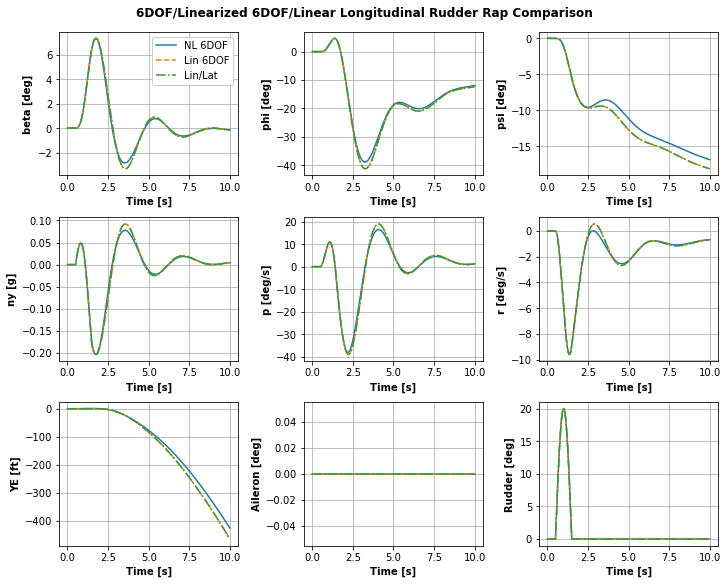

In [23]:

def get_linearized_lat(aircraft, trim_X0, rho = RHO_SL_SLUG_FT3, g = G_FT_S2):
    """
    Obtains linearized lat/dir state-space matrices for the supplied aircraft object
    at specified airspeed and trim conditions. Aircraft must be set at a control
    setting and throttle level that puts it at or near a valid trim state,
    or the linearization will be invalid

    Parameters
    ----------
    aircraft : Aircraft
        Aircraft object which implements "get_thrust," "get_mass_props," and 
        "get_aero_coeffs" properties
    trim_X0 : array
        Trim initial conditions for the 6DOF solver
    rho : float, optional
        Atmospheric density at trim altitude. Default value is sea level in slug/ft^3
    g : float, optional
        Gravitional acceleration value. Default is sea level value in ft/s^2

    Returns
    -------
    lti_sys : LinearTimeInvariant
        Returns a state-space representation of a linear time invariant system
        obtained by the linearization. States are the lat-dir states, inputs are
        the control inputs, and outputs are the lat-dir outputs
    y_0 : Array
        Vector of lat-dir linear system outputs at the trim state

    """
    
    # Aerodynamic derivatives
    stab_coeffs, control_coeffs = get_aero_derivatives_lat(aircraft, trim_X0)
    Cyb, Clb, Cnb, Clp, Cnp, Clr, Cnr = stab_coeffs
    Cyda, Clda, Cnda, Cydr, Cldr, Cndr = control_coeffs
    
    # Inertial, dynamic pressure, and reference quantities
    mass = aircraft.mass
    Ixx = aircraft.Ixx
    Izz = aircraft.Izz
    Ixz = aircraft.Ixz
    Izzh = Izz/Ixx
    Ixzh = Ixz/Ixx
    Ih = Izzh - Ixzh*Ixzh
    
    u0 = trim_X0[0]
    w0 = trim_X0[2]
    theta0 = trim_X0[7]
    VTAS = np.sqrt(u0*u0 + w0*w0)
    qinf = 0.5*rho*VTAS**2
    sref = aircraft.sref
    bref = aircraft.bref
    Qbar = qinf*sref*bref
    
    # A matrix definition (state transition)
    A = np.array([[qinf*sref*Cyb/(mass*VTAS), w0, -u0, g*np.cos(theta0), 0., 0.], # v
                  [Qbar/VTAS*(Izzh/Ih*Clb + Ixzh/Ih*Cnb)/Ixx, 
                   Qbar*bref/(2*VTAS)*(Izzh/Ih*Clp + Ixzh/Ih*Cnp)/Ixx,
                   Qbar*bref/(2*VTAS)*(Izzh/Ih*Clr + Ixzh/Ih*Cnr)/Ixx,
                   0, 0., 0.], # p
                  [Qbar/VTAS*(Ixzh/Ih*Clb + 1./Ih*Cnb)/Ixx, 
                   Qbar*bref/(2*VTAS)*(Ixzh/Ih*Clp + 1./Ih*Cnp)/Ixx,
                   Qbar*bref/(2*VTAS)*(Ixzh/Ih*Clr + 1./Ih*Cnr)/Ixx,
                   0, 0., 0.], # r
                  [0., 1., np.tan(theta0), 0., 0., 0.], # phi
                  [0, 0, 1/np.cos(theta0), 0, 0., 0.], # psi
                  [1., 0., 0., -w0, u0*np.cos(theta0) + w0*np.sin(theta0), 0.], # YE
                 ])
    
    
    # B matrix definition (input influence)
    B = np.array([[qinf*sref*Cyda/mass, qinf*sref*Cydr/mass], # v 
                  [Qbar*(Izzh/Ih*Clda + Ixzh/Ih*Cnda)/Ixx, Qbar*(Izzh/Ih*Cldr + Ixzh/Ih*Cndr)/Ixx], # p
                  [Qbar*(Ixzh/Ih*Clda + 1/Ih*Cnda)/Ixx, Qbar*(Ixzh/Ih*Cldr + 1/Ih*Cndr)/Ixx],   # r
                  [0., 0.,],   # phi
                  [0., 0.,],   # psi
                  [0., 0.,]])  # YE
    
    # C matrix definition (state output)
    C = np.array([[1/VTAS, 0., 0., 0., 0., 0.], # beta
                  [0., 1, 0., 0., 0., 0.],  # p
                  [0., 0., 1., 0., 0., 0.],  # r
                  [0., 0., 0., 1., 0., 0.],  # phi
                  [0., 0., 0., 0., 1., 0.],  # psi
                  [qinf*sref*Cyb/(mass*g*VTAS), 
                  0., 0., 0., 0., 0.],  # ny
                  [0., 0., 0., 0., 0., 1],  # YE
                  [0., 0., 0., 0., 0., 0.], # Delta aileron
                  [0., 0., 0., 0., 0., 0.]]) # Delta rudder
    
    # D matrix definition (input feed-forward)
    D = np.array([[0., 0.], 
                  [0., 0.],
                  [0., 0.],
                  [0., 0.],
                  [0., 0.],
                  [qinf*sref*Cyda/(mass*g), qinf*sref*Cydr/(mass*g)],
                  [0., 0.],
                  [1., 0.],
                  [0., 1.]])
    
    
    # Initial output values from indexed 6DOF EOM outputs
    # V, alpha, beta, [0, 1, *2*,
    # p, q, r,         *3*, 4, *5*,
    # phi, theta, psi, *6*, 7, *8*
    # xe, ye, ze,      9, *10*, 11,
    # ax, ay, az,      12, *13*, 14, 
    # roll_control, pitch_control, yaw_control    *15*, 16, *17*]
    y_0 = eom_6dof(0., trim_X0, aircraft, output_mode = True)[[2, 3, 5, 6, 8, 13, 10, 15, 17]]

    return lti(A, B, C, D), y_0

# Checkout of linearization against previous results
linsys_lat, y_0_lat = get_linearized_lat(f106, trim_X0)

# print(np.linalg.eigvals(linsys_lat.A))
print(np.linalg.matrix_rank(linsys_lat.A.T))
# print(linsys_lat.A)

# lat_coeffs = [1, 3, 5, 6, 8, 10]
# A_check = np.array([s[lat_coeffs] for s in linsys.A[lat_coeffs]])

# Run simulation
roll_hist = lambda t, x: 0.
yaw_hist = lambda t, x: 0.
f106.set_aero_controls(roll = zero, 
                       pitch = pitch_trim, 
                       yaw = rudder_rap)
    
eom = lambda t, x: eom_6dof(t, x, f106)
sol = solve_ivp(eom, [0, T], trim_X0, t_eval = time)
# u, v, w, p, q, r, phi, theta, psi, Xe, Ye, Ze = sol.y
outputs_nl = np.array([eom_6dof(ti, yi, f106, output_mode = True) for ti, yi in zip(time, sol.y.T)]).T

U = np.vstack([zero(sol.t, trim_X0), 
               pitch_trim(sol.t, trim_X0), 
               rudder_rap(sol.t, trim_X0)]).T

# Numerical linear system
_, outputs_lin, _ = lsim(linsys, U, sol.t)
outputs_lin += y_0

# Explictly written longitudinal system
U = np.vstack([zero(sol.t, trim_X0),
               rudder_rap(sol.t, trim_X0)]).T
_, outputs_lin_lat, _ = lsim(linsys_lat, U, sol.t)
outputs_lin_lat += y_0_lat

fig, ax_dict = plt.subplot_mosaic([['beta [deg]', 'phi [deg]', 'psi [deg]'],
                                   ['ny [g]',  'p [deg/s]', 'r [deg/s]'],
                                   ['YE [ft]', 'Aileron [deg]', 'Rudder [deg]']],
                                figsize = (10, 8), 
                                constrained_layout = True)

for outputs, lstyle, label in zip([outputs_nl, outputs_lin.T, outputs_lin_lat.T], 
                                   [lstyle_nl, lstyle_lin, '-.'],
                                     ['NL 6DOF', 'Lin 6DOF', 'Lin/Lat']):
    try:
        V, alpha, beta, p, q, r, phi, theta, psi, xe, ye, ze, ax, ay, az, roll_control, pitch_control, yaw_control = outputs
        
        ax_dict['beta [deg]'].plot(sol.t, beta*RAD_DEG, lstyle, label = label)
        ax_dict['p [deg/s]'].plot(sol.t, p*RAD_DEG, lstyle, label = label)
        ax_dict['r [deg/s]'].plot(sol.t, r*RAD_DEG, lstyle, label = label)
        ax_dict['phi [deg]'].plot(sol.t, phi*RAD_DEG, lstyle, label = label)
        ax_dict['psi [deg]'].plot(sol.t, psi*RAD_DEG, lstyle, label = label)
        ax_dict['ny [g]'].plot(sol.t, ay, lstyle, label = label)
        ax_dict['YE [ft]'].plot(sol.t, ye, lstyle, label = label)
        ax_dict['Aileron [deg]'].plot(sol.t, roll_control*RAD_DEG, lstyle, label = label)
        ax_dict['Rudder [deg]'].plot(sol.t, yaw_control*RAD_DEG, lstyle, label = label)

        
    except:
        beta, p, r, phi, psi, ay, ye, da, dr = outputs
        
        ax_dict['beta [deg]'].plot(sol.t, beta*RAD_DEG, lstyle, label = label)
        ax_dict['p [deg/s]'].plot(sol.t, p*RAD_DEG, lstyle, label = label)
        ax_dict['r [deg/s]'].plot(sol.t, r*RAD_DEG, lstyle, label = label)
        ax_dict['phi [deg]'].plot(sol.t, phi*RAD_DEG, lstyle, label = label)
        ax_dict['psi [deg]'].plot(sol.t, psi*RAD_DEG, lstyle, label = label)
        ax_dict['ny [g]'].plot(sol.t, ay, lstyle, label = label)
        ax_dict['YE [ft]'].plot(sol.t, ye, lstyle, label = label)
        ax_dict['Aileron [deg]'].plot(sol.t, roll_control*RAD_DEG, lstyle, label = label)
        ax_dict['Rudder [deg]'].plot(sol.t, yaw_control*RAD_DEG, lstyle, label = label)


ax_dict['beta [deg]'].legend(loc = 'upper right', framealpha = 1.)
for key, a in ax_dict.items():
    a.set_xlabel('Time [s]', fontweight = 'bold')
    a.set_ylabel(key, fontweight = 'bold')
    a.grid()

fig.suptitle('6DOF/Linearized 6DOF/Linear Longitudinal Rudder Rap Comparison', fontweight = 'bold')


In this comparison the linearized 6DOF and explicitly written lateral/directional system matrices are essentially line-on-line with each other.

### Eigenvalues Comparison

Before wrapping up this quite involved section, we'll check on the eigenvalues of the longitudinal and lateral/directional systems and compare them to those of the linearized 6DOF equations. 

Longitudinal Eigenvalues
0j
0j
(-0.3993433950592043+1.3534701948960448j)
(-0.3993433950592043-1.3534701948960448j)
(-0.029365812136500642+0.12486700282909875j)
(-0.029365812136500642-0.12486700282909875j)


Lateral/Directional Eigenvalues
0j
0j
(-0.5084016223988624+1.7681776670880796j)
(-0.5084016223988624-1.7681776670880796j)
(-1.4903456465173621+0j)
(-0.1353389500710364+0j)


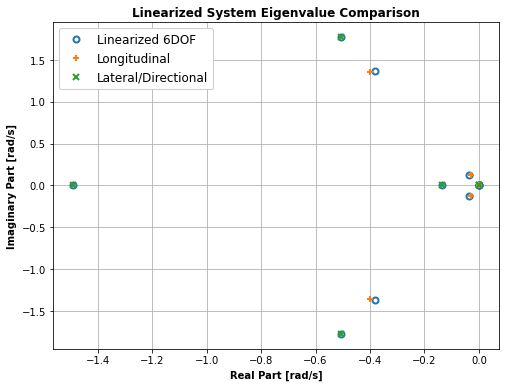

In [32]:
eigvals_all = np.linalg.eigvals(linsys.A)
eigvals_long = np.linalg.eigvals(linsys_long.A)
eigvals_lat = np.linalg.eigvals(linsys_lat.A)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

ax.plot(np.real(eigvals_all), np.imag(eigvals_all), 'o', markerfacecolor = 'None',
       label = 'Linearized 6DOF', markeredgewidth = 2.)
ax.plot(np.real(eigvals_long), np.imag(eigvals_long), '+', label = 'Longitudinal',
        markeredgewidth = 2.)
ax.plot(np.real(eigvals_lat), np.imag(eigvals_lat), 'x', label = 'Lateral/Directional',
        markeredgewidth = 2.)
ax.grid()

ax.set_xlabel('Real Part [rad/s]', fontweight = 'bold')
ax.set_ylabel('Imaginary Part [rad/s]', fontweight = 'bold')
ax.set_title('Linearized System Eigenvalue Comparison', fontweight = 'bold')
ax.legend(loc = 'upper left', framealpha = 1., fontsize = 12)

print('Longitudinal Eigenvalues')
for eigval in eigvals_long:
    print(eigval)
    
print('\n')

print('Lateral/Directional Eigenvalues')
for eigval in eigvals_lat:
    print(eigval)

The eigenvalues confirm a slight mismatch between the longitudinal and full-up 6DOF linearization, but the lateral/directional values are in very good agreement. We also confirm that the zero-eigenvalue modes are evenly split between the longitudinal and lateral/directional systems. The longitudinal system displays the expected pair of complex eigenvalues (a higher frequency "short period" and low frequency "phugoid" mode) while the lateral/directional system has a single set of complex eigenvalues (the oscillatory "Dutch Roll" mode) and two eigenvalues on the real axis (a high time-constant "roll mode" and low time constant "spiral mode"). 

That concludes the development of the linearized equations about level trim conditions. The next step is to analyze the longitudinal and lateral/directional modes in more detail and with more aircraft examples. 